# Setup Environment

In [1]:
# Importing necessary libraries

# Standard libraries
import datetime
import random
import logging
import os
from pathlib import Path

# Data manipulation libraries
import fastf1
import numpy as np
import pandas as pd

#  visualization libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
import sklearn
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# Hyperparameter optimization library
import optuna
from optuna.trial import TrialState


print(f"FastF1 version: {fastf1.__version__}")
print(f"numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"torch version: {torch.__version__}")
print(f"optuna version: {optuna.__version__}")

FastF1 version: 3.8.3
numpy version: 2.5.2
Pandas version: 2.3.3
matplotlib version: 3.11.1
seaborn version: 0.13.2
sklearn version: 1.9.0
torch version: 2.13.0+cu132
optuna version: 4.9.0


In [51]:
# Create necessary directories for saving models and results

model_dir   = Path("models")

eda_plots_dir           = Path("plots/EDA")
preprocessing_plots_dir = Path("plots/Preprocessing")
base_model_plots_dir    = Path("plots/Base_Model")
best_model_plots_dir    = Path("plots/Best_Model")

model_dir.mkdir(parents=True, exist_ok=True)
eda_plots_dir.mkdir(parents=True, exist_ok=True)
preprocessing_plots_dir.mkdir(parents=True, exist_ok=True)
base_model_plots_dir.mkdir(parents=True, exist_ok=True)
best_model_plots_dir.mkdir(parents=True, exist_ok=True)

# Data Collection and Preprocessing

In [52]:
# Download and save F1 data using fastf1

# Create directories for raw and cached data if they don't exist
if not Path("f1_data_raw").exists():
    Path("f1_data_raw").mkdir()
if not Path("f1_data_cache").exists():
    Path("f1_data_cache").mkdir()

fastf1.Cache.enable_cache('f1_data_cache')      # Enable caching to speed up data retrieval
fastf1.set_log_level(logging.ERROR)             # Set log level to ERROR to reduce verbosity

# Helper function to get data for a specific year and features
def get_year_data(year):
    print(f"Processing {year}...")
    all_laps = []

    # Loop through all events in the specified year
    schedule = fastf1.get_event_schedule(year)
    for i in schedule.index:
        event = schedule.loc[i]
        print(f"Loading {event['EventName']} {year}...")
        # Skip testing sessions (testing session data is completely different)
        if event['EventFormat'] == 'testing':
            continue

        try:
            session = fastf1.get_session(year, event['EventName'], 'R')
            session.load()
            
            laps = session.laps.copy()
            laps['Year'] = year
            laps['Event'] = event['EventName']

            weather = session.weather_data
            laps_with_weather = pd.merge_asof(
            laps.sort_values('LapStartTime'),
            weather.sort_values('Time'),
            left_on='LapStartTime',
            right_on='Time',
            direction='backward'  # takes the most recent weather reading
            )

            # We got "Time_x" and "Time_y" columns after the merge, we can drop "Time_y"
            laps_with_weather.drop(columns=['Time_y'], inplace=True)
            laps_with_weather.rename(columns={'Time_x': 'Time'}, inplace=True)
            
            all_laps.append(laps_with_weather)
        except Exception as e:
            print(f"Could not load {event['EventName']} {year}: {e}")    

    return pd.concat(all_laps) if all_laps else pd.DataFrame()

# Collect data for the specified years and features
years_to_process = [2020, 2021, 2022, 2023, 2024, 2025]
for year in years_to_process:   
    if not Path(f"f1_data_raw/f1_data_{year}.csv").exists():
        year_data = get_year_data(year)
        year_data.to_csv(f"f1_data_raw/f1_data_{year}.csv", index=False)
        print(f"Saved data for {year} to f1_data_{year}.csv")
    else:
        print(f"Data for {year} already exists. Skipping download.")
    

Data for 2020 already exists. Skipping download.
Data for 2021 already exists. Skipping download.
Data for 2022 already exists. Skipping download.
Data for 2023 already exists. Skipping download.
Data for 2024 already exists. Skipping download.
Data for 2025 already exists. Skipping download.


In [53]:
# Load the data to a dataframe 
df_2020 = pd.read_csv("f1_data_raw/f1_data_2020.csv", low_memory=False)
df_2021 = pd.read_csv("f1_data_raw/f1_data_2021.csv", low_memory=False)
df_2022 = pd.read_csv("f1_data_raw/f1_data_2022.csv", low_memory=False)
df_2023 = pd.read_csv("f1_data_raw/f1_data_2023.csv", low_memory=False)
df_2024 = pd.read_csv("f1_data_raw/f1_data_2024.csv", low_memory=False)
df_2025 = pd.read_csv("f1_data_raw/f1_data_2025.csv", low_memory=False)

df_full = pd.concat([df_2020, df_2021, df_2022, df_2023, df_2024, df_2025], ignore_index=True)
df_full.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Event', 'AirTemp', 'Humidity',
       'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed'],
      dtype='object')

In [54]:
# count number of row with null values in each column
null_counts = df_full.isnull().sum()
null_counts

Time                       0
Driver                     0
DriverNumber               0
LapTime                 2433
LapNumber                  0
Stint                    354
PitOutTime            138504
PitInTime             138463
Sector1Time             3085
Sector2Time              260
Sector3Time              414
Sector1SessionTime      3413
Sector2SessionTime       260
Sector3SessionTime       414
SpeedI1                  204
SpeedI2                 1091
SpeedFL                 5134
SpeedST                  279
IsPersonalBest           148
Compound                 780
TyreLife                1058
FreshTyre                  0
Team                       0
LapStartTime               0
LapStartDate               0
TrackStatus               23
Position                 202
Deleted                    0
DeletedReason         141720
FastF1Generated            0
IsAccurate                 0
Year                       0
Event                      0
AirTemp                   20
Humidity      

In [55]:
# Transformation: LapTime and sector times to seconds, TrackStatus bitmask to boolean columns

# 1. Transform LapTime and sector times to seconds for easier analysis
def transform_lap_sector_time(df):
    time_columns = ['Time','LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
    
    # Transform time columns to timedelta, handling errors by coercing invalid formats to NaT
    for col in time_columns:
        if col in df.columns:
            df[col] = pd.to_timedelta(df[col], errors='coerce')
    
    # Change LapTime to seconds for easier analysis
    df['Time'] = df['Time'].dt.total_seconds()
    df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()
    df['Sector1Time'] = df['Sector1Time'].dt.total_seconds()
    df['Sector2Time'] = df['Sector2Time'].dt.total_seconds()
    df['Sector3Time'] = df['Sector3Time'].dt.total_seconds()
    df.drop(columns=['LapTime'], inplace=True)
    
    return df

# 2. Fill any missing gap in weather data 
def fill_weather_gaps(df):
    weather_columns = ['AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'WindSpeed', 'WindDirection']
    for col in weather_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
            df[col] = df[col].ffill().bfill()
    return df

# 3. Remove inaccurate laps, deleted laps, and laps with pit stop times
def clean_race_data(df):
    # Remove inaccurate laps
    df = df[df['IsAccurate'] == True].copy()

    # Remove deleted laps, may be due to track limits or other reasons
    df = df[df['Deleted'] != True].copy()
    
    # remove laps with pit stop times (PitInTime and PitOutTime) as they are not useful for lap time prediction
    df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()].copy()

    return df

# 4. Remove contextual outliers based on mean and standard deviation within each Event and Year group
numerical_features = ['LapTimeSeconds', 'Sector1Time', 'Sector2Time', 'Sector3Time', 
                      'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']

def remove_contextual_outliers(df, features, n_stds=3):
    df = df.copy().reset_index(drop=True)
    groups = ['Year', 'Event']
    
    mask = pd.Series(True, index=df.index)
    
    for col in features:
        group_mean = df.groupby(groups)[col].transform('mean')
        group_std = df.groupby(groups)[col].transform('std')
        
        lower = group_mean - n_stds * group_std
        upper = group_mean + n_stds * group_std
        
        col_mask = (df[col] >= lower) & (df[col] <= upper)
        mask = mask & col_mask
    
    return df[mask].reset_index(drop=True)

# 5. Process TrackStatus bitmask into separate boolean columns
def process_track_status(df):
    status_map = {
        'IsSafetyCar': 4,
        'IsRedFlag': 8,
        'IsVSC': 16,
        'IsPitClosed': 32,
        'IsSCEnding': 128
    }

    # drop rows with NaN in TrackStatus
    df = df.dropna(subset=['TrackStatus']).copy()

    # Create new columns for each status based on the TrackStatus bitmask
    for col_name, bit_value in status_map.items():
        df[col_name] = df['TrackStatus'].apply(lambda x: 1 if (int(x) & bit_value) else 0)
    
    df = df.drop(columns=['TrackStatus'])
    
    return df

In [56]:
# Drop unnecessary columns and reorder for better readability

# Drop unnecessary columns
drop_list = [   'DriverNumber','PitOutTime', 'PitInTime',
                'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
                'LapStartTime', 'LapStartDate', 
                'Deleted', 'DeletedReason',
                'FastF1Generated', 'IsAccurate',
                'Humidity', 'Pressure', 'WindSpeed', 'WindDirection']

# reorder columns for better readability
desired_order = [   'Year', 'Event', 'Driver', 'Team', 'Time','Position', 'LapNumber',                  # Basic Info
                    'LapTimeSeconds', 'Sector1Time', 'Sector2Time','Sector3Time', 'IsPersonalBest',     # Lap performance
                    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',                                         # Speed
                    'Compound', 'TyreLife', 'FreshTyre', 'Stint',                                       # Tyre Strategy
                    'IsSafetyCar','IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',                    # Race Conditions
                    'AirTemp', 'TrackTemp', 'Rainfall',  ]                                              # Weather Conditions

def reorder_columns(df, desired_order):
    # Get the current columns in the DataFrame
    current_columns = df.columns.tolist()
    
    # Create a new order based on desired_order and current_columns
    new_order = [col for col in desired_order if col in current_columns] + [col for col in current_columns if col not in desired_order]

    # Reorder the DataFrame columns
    df = df[new_order]
    
    return df

In [57]:
# Preprocess the data for each year
def preprocess_data(df):
    df = df.copy()
    print(f"Data shape before preprocessing: {df.shape}")

    df = transform_lap_sector_time(df)
    print(f"Data shape after transforming lap and sector times: {df.shape}")

    df = fill_weather_gaps(df)
    print(f"Data shape after filling weather gaps: {df.shape}")

    df = process_track_status(df)
    print(f"Data shape after processing TrackStatus: {df.shape}")

    df = clean_race_data(df)
    print(f"Data shape after cleaning race data: {df.shape}")

    df = remove_contextual_outliers(df, numerical_features, n_stds=3)
    print(f"Data shape after removing contextual outliers: {df.shape}")

    df = df.drop(columns=drop_list, errors='ignore')
    print(f"Data shape after dropping unnecessary columns: {df.shape}")

    df = reorder_columns(df, desired_order)
    print(f"Data shape after reordering columns: {df.shape}")

    df = df.dropna()
    print(f"Data shape after dropping rows with NaN values: {df.shape}")
    
    return df

df_full_clean = preprocess_data(df_full)
print(f"Data shape after preprocessing: {df_full_clean.shape}")

Data shape before preprocessing: (143396, 40)
Data shape after transforming lap and sector times: (143396, 40)
Data shape after filling weather gaps: (143396, 40)
Data shape after processing TrackStatus: (143373, 44)
Data shape after cleaning race data: (122030, 44)
Data shape after removing contextual outliers: (116628, 44)
Data shape after dropping unnecessary columns: (116628, 28)
Data shape after reordering columns: (116628, 28)
Data shape after dropping rows with NaN values: (115725, 28)
Data shape after preprocessing: (115725, 28)


In [58]:
# Get columns of the cleaned dataframe
df_full_clean.columns

Index(['Year', 'Event', 'Driver', 'Team', 'Time', 'Position', 'LapNumber',
       'LapTimeSeconds', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'IsPersonalBest', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
       'Compound', 'TyreLife', 'FreshTyre', 'Stint', 'IsSafetyCar',
       'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding', 'AirTemp',
       'TrackTemp', 'Rainfall'],
      dtype='object')

# Exploratory Data Analysis

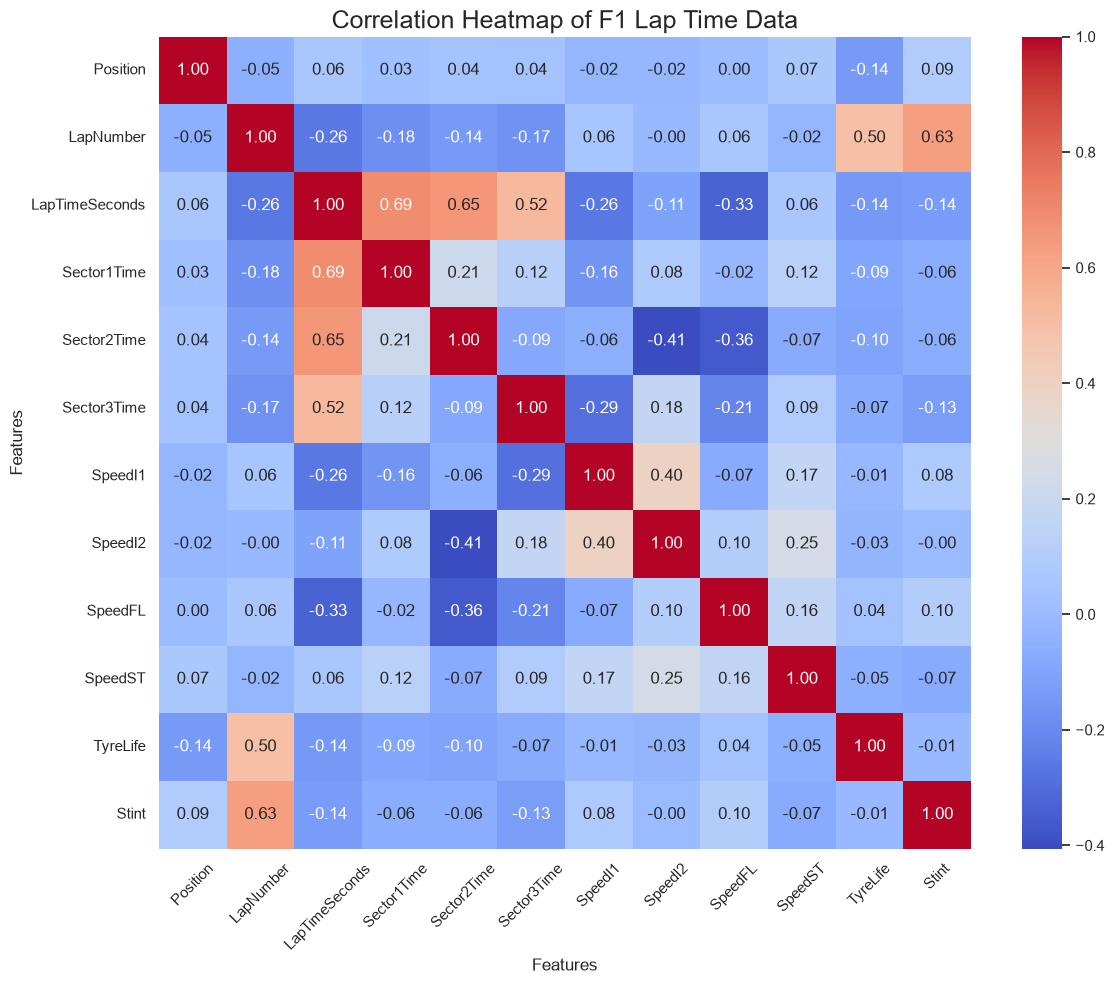

In [59]:
# Correlation Heatmap
numerical_columns = ['Position', 'LapNumber', 'LapTimeSeconds', 
                     'Sector1Time', 'Sector2Time', 'Sector3Time',
                     'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 
                     'TyreLife', 'Stint']


df_analysis = df_full_clean.copy()
df_analysis = df_analysis[numerical_columns]

plt.figure(figsize=(12, 10))
sns.heatmap(df_analysis.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of F1 Lap Time Data", fontsize=18)
plt.xlabel("Features", fontsize=12)
plt.tick_params(axis='x', labelrotation=45)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.savefig(eda_plots_dir / "01_correlation_heatmap.png", dpi=300)
plt.show()

<Figure size 1000x600 with 0 Axes>

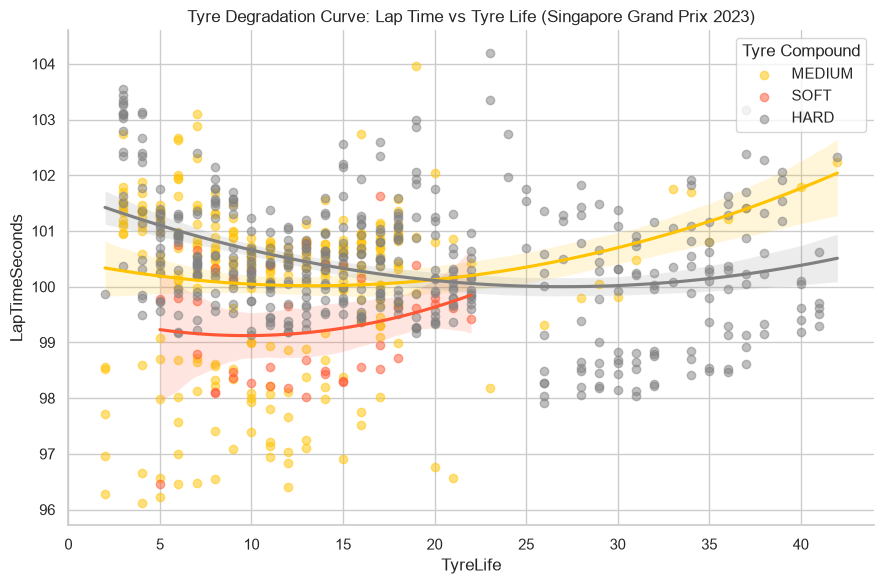

<Figure size 1000x600 with 0 Axes>

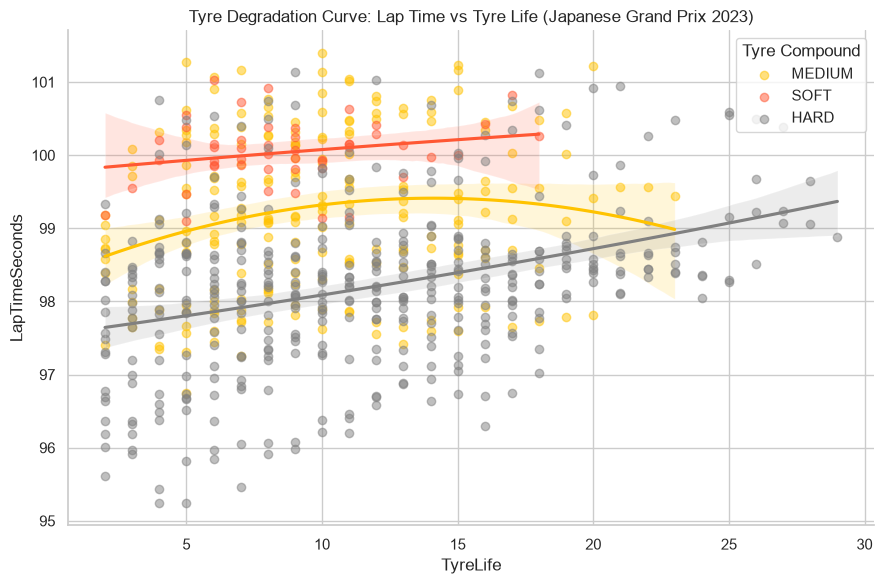

<Figure size 1000x600 with 0 Axes>

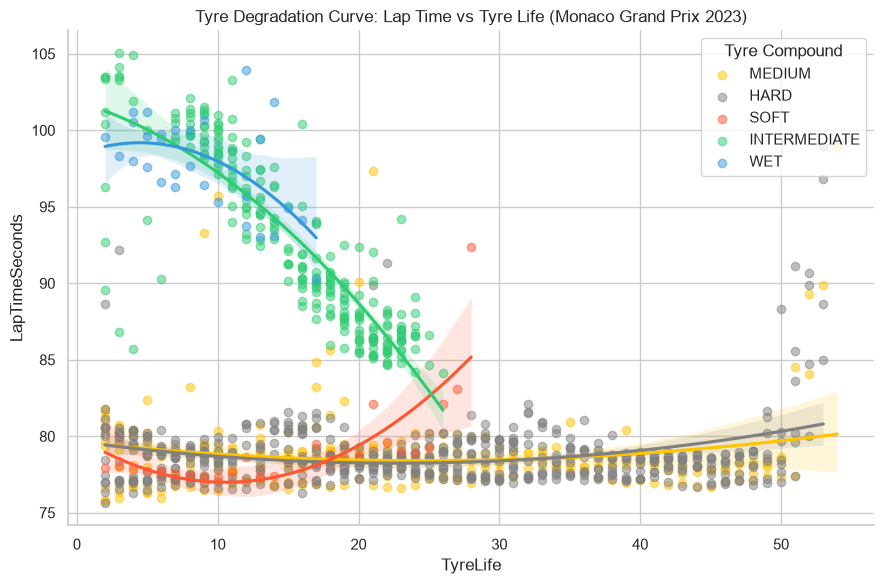

In [60]:
# Tyre Degradation Curve: Lap Time vs Tyre Life

def plot_tyre_degradation(df, event='Italian Grand Prix', year=2023, png_name='tyre_degradation_curve'):
    sample_df = df[(df['Event'] == event) & (df['Year'] == year)]

    # only keep data where all the track status flags are 0 (no safety car, no red flag, no VSC, no pit closed, no SC ending)
    sample_df = sample_df[(sample_df['IsSafetyCar'] == 0) & 
                           (sample_df['IsRedFlag'] == 0) & 
                           (sample_df['IsVSC'] == 0) & 
                           (sample_df['IsPitClosed'] == 0) & 
                           (sample_df['IsSCEnding'] == 0)]
    
    # cap the lap times to a maximum of 120 seconds to remove outliers
    sample_df = sample_df[sample_df['LapTimeSeconds'] <= 110]

    color_palette = {
        'SOFT': '#FF5733',          # Red
        'MEDIUM': '#FFC300',        # Yellow
        'HARD': '#808080',          # Gray
        'INTERMEDIATE': '#2ECC71',  # Green
        'WET': '#3498DB'            # Blue
    }
    plt.figure(figsize=(10, 6))
    sns.lmplot(
        data=sample_df, 
        x='TyreLife', 
        y='LapTimeSeconds', 
        hue='Compound', 
        palette=color_palette,
        height=6, 
        aspect=1.5,
        scatter_kws={'alpha': 0.5},
        order=2,
        legend=False
    )
    plt.title(f'Tyre Degradation Curve: Lap Time vs Tyre Life ({event} {year})')
    plt.grid(True)
    plt.legend(title='Tyre Compound', loc='upper right')
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()



plot_tyre_degradation(df_full_clean, event='Singapore Grand Prix', year=2023, png_name='02_tyre_degradation_Singapore_2023.png')
plot_tyre_degradation(df_full_clean, event='Japanese Grand Prix',  year=2023, png_name='03_tyre_degradation_Japanese_2023.png')
plot_tyre_degradation(df_full_clean, event='Monaco Grand Prix',    year=2023, png_name='04_tyre_degradation_Monaco_2023.png')

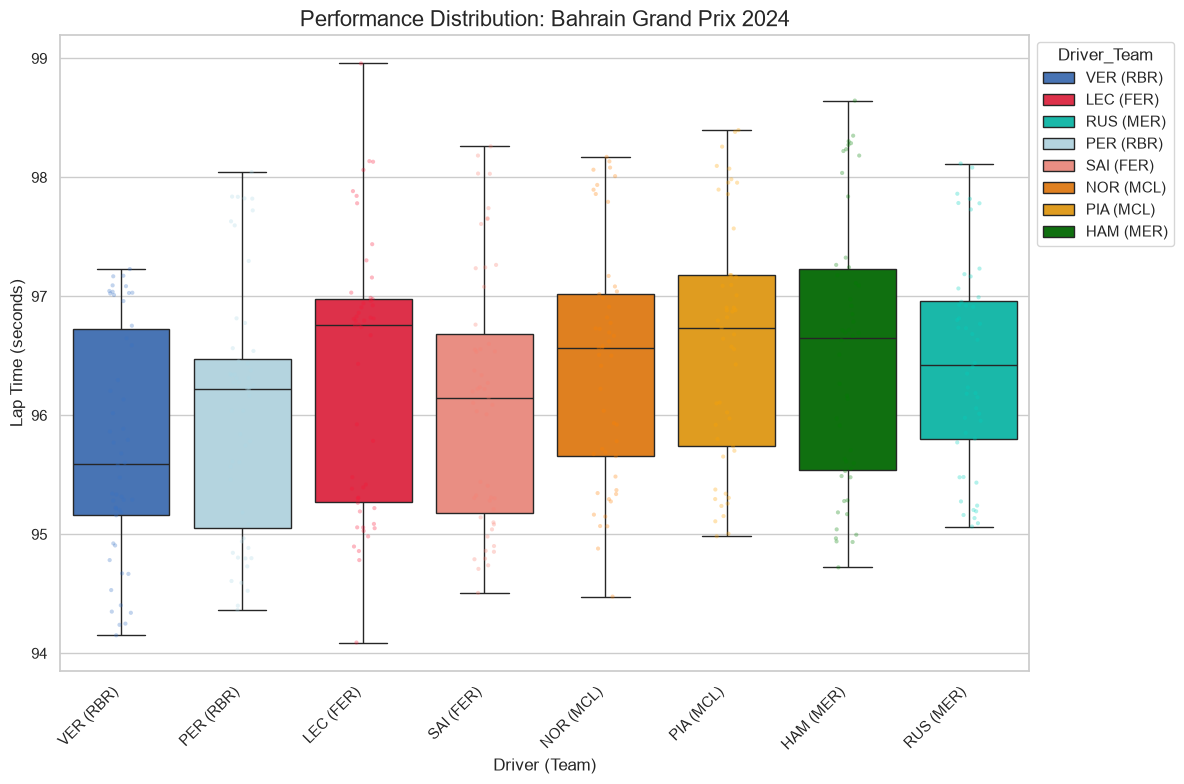

In [61]:
# Driver and Team Effect on Lap Time
def plot_driver_team_effect(df, event='Singapore Grand Prix', year=2023, png_name='driver_team_effect'):
    # Filter the dataframe for the specified event and year, and only include the big 4 teams
    team_abbr = {'Red Bull Racing': 'RBR', 'Ferrari': 'FER', 'McLaren': 'MCL', 'Mercedes': 'MER'}
    subset = df[(df['Team'].isin(team_abbr.keys())) & (df['Event'] == event) & (df['Year'] == year)].copy()
    subset['Driver_Team'] = subset['Driver'] + ' (' + subset['Team'].map(team_abbr) + ')'

    custom_order = ['VER (RBR)', 'PER (RBR)', 'LEC (FER)', 'SAI (FER)', 'NOR (MCL)', 'PIA (MCL)', 'HAM (MER)', 'RUS (MER)']

    color_map = {
        'VER (RBR)': '#3671C6', 'PER (RBR)': 'lightblue',
        'LEC (FER)': '#F91536', 'SAI (FER)': 'salmon',
        'NOR (MCL)': '#FF8000', 'PIA (MCL)': '#FFA500',
        'HAM (MER)': 'green', 'RUS (MER)': '#00D2BE'
    }

    plt.figure(figsize=(12, 8))

    sns.boxplot(
        data=subset, x='Driver_Team', y='LapTimeSeconds', 
        hue='Driver_Team',       
        palette=color_map, 
        order=custom_order,      
        fliersize=0,
        legend=True             
    )
    sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))
    
    sns.stripplot(
        data=subset, x='Driver_Team', y='LapTimeSeconds', 
        hue='Driver_Team',       
        palette=color_map,
        order=custom_order,
        size=3, alpha=0.3,
        legend=False             
    )

    plt.title(f'Performance Distribution: {event} {year}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Driver (Team)', fontsize=12)
    plt.ylabel('Lap Time (seconds)', fontsize=12)
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()

plot_driver_team_effect(df_full_clean, event='Bahrain Grand Prix', year=2024, png_name='05_driver_team_effect_Bahrain_2024.png')

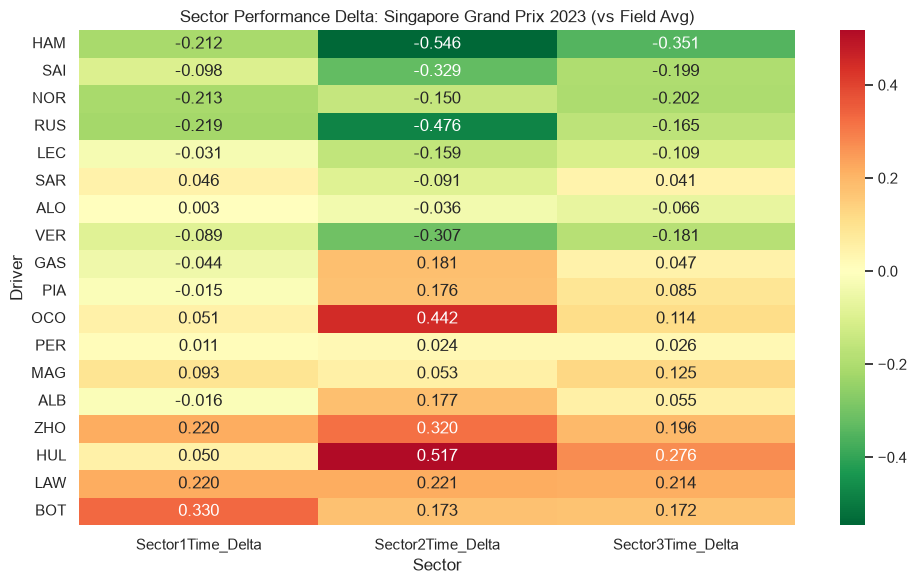

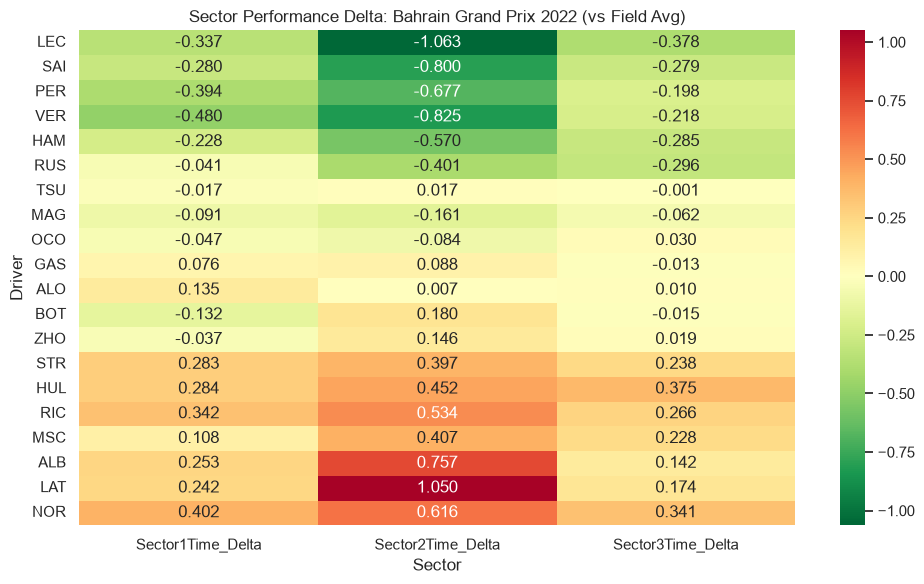

In [62]:
# Sector Performance Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

def plot_sector_performance_heatmap(df, event='Singapore Grand Prix', year=2023, png_name='sector_performance_heatmap'):
    # 1. Filter the dataframe for the specified event and year
    subset = df[(df['Event'] == event) & (df['Year'] == year)].copy()
    sector_cols = ['Sector1Time', 'Sector2Time', 'Sector3Time']

    # 2. Calculate the delta from the mean for each sector
    for col in sector_cols:
        subset[f'{col}_Delta'] = subset[col] - subset[col].mean()

    subset = subset.dropna(subset=['LapTimeSeconds'])
    driver_order = subset.groupby('Driver')['LapTimeSeconds'].median().sort_values().index

    # 4. Pivot the dataframe to have drivers as rows and sectors as columns
    pivot_df = subset.pivot_table(index='Driver', values=[f'{c}_Delta' for c in sector_cols])
    pivot_df = pivot_df.reindex(driver_order)
    
    # 5. Create the heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, cmap='RdYlGn_r', center=0, fmt=".3f")
    plt.title(f'Sector Performance Delta: {event} {year} (vs Field Avg)')
    plt.xlabel('Sector')
    plt.ylabel('Driver')
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()

plot_sector_performance_heatmap(df_full_clean, event='Singapore Grand Prix', year=2023, png_name='06_sector_performance_heatmap_Singapore_2023.png')
plot_sector_performance_heatmap(df_full_clean, event='Bahrain Grand Prix', year=2022, png_name='07_sector_performance_heatmap_Bahrain_2022.png')

<Figure size 1000x600 with 0 Axes>

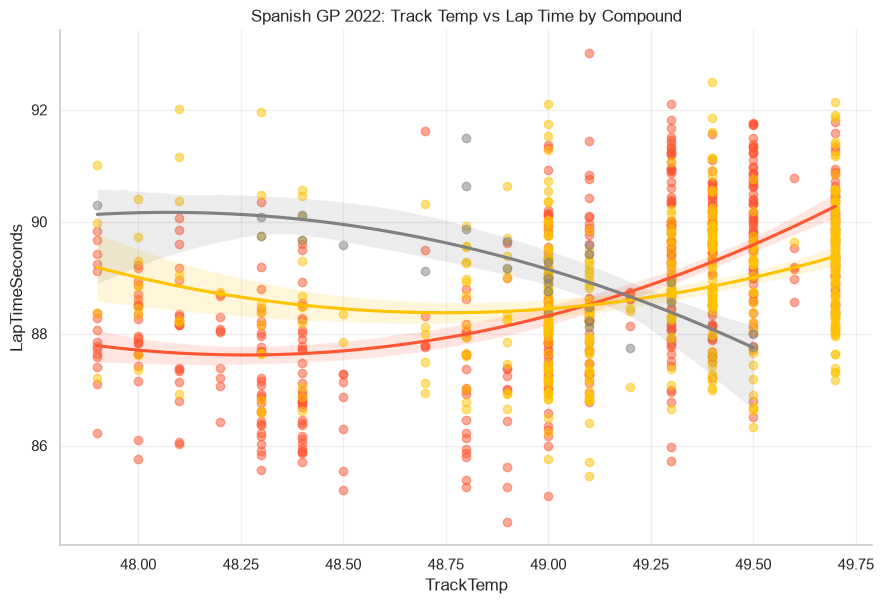

In [63]:
# Scatter Plot: Track Temperature vs Lap Time by Compound

# Filter the dataframe for the Singapore Grand Prix 2023
spanish_2022 = df_full_clean[(df_full_clean['Year'] == 2022) & (df_full_clean['Event'] == 'Spanish Grand Prix')]

color_palette = {
    'SOFT': '#FF5733',          # Red
    'MEDIUM': '#FFC300',        # Yellow
    'HARD': '#808080',          # Gray
    'INTERMEDIATE': '#2ECC71',  # Green
    'WET': '#3498DB'            # Blue
}

# plot the scatter plot with regression lines for each compound
plt.figure(figsize=(10, 6))
sns.lmplot(
    data=spanish_2022, 
    x='TrackTemp', 
    y='LapTimeSeconds', 
    hue='Compound', 
    palette=color_palette,
    height=6, 
    aspect=1.5,
    scatter_kws={'alpha': 0.5},
    order=2,
    legend=False
)

plt.title('Spanish GP 2022: Track Temp vs Lap Time by Compound')
plt.grid(True, alpha=0.3)
plt.savefig(eda_plots_dir / "08_track_temp_vs_lap_time_Spanish_2022.png", dpi=300)
plt.show()

# Feature Engineering

**Additional Feature Engineering & Data Notes**

1. **Extended Environmental & Compound Indexing**
   * **Humidity & Pressure:** Atmospheric density affects downforce/vertical load and tire cooling, shifting optimal tire working windows.
   * **`TrackTemp_Normalized_By_Compound`:** Interaction feature mapping track surface temperature against Pirelli compound hardness (C1–C5) to model compound-specific thermal degradation.

2. **Regulatory Shift Handling (`RuleSet`)**
   * **Categorical Rule Flag:** Include discrete rule-epoch indicators (e.g., `2018–2021`, `2022–2025`, `2026+`) to account for structural shifts in vehicle mass, aerodynamics, and tire physics.

3. **Dynamic Vehicle Physics & Performance Drift**
   * **Fuel Burn & Mass Sensitivity:** Model dynamic vehicle weight loss (~1.5 kg/lap) to unmask underlying tire degradation from weight-reduction pace gains (~0.3s / 10kg).
   * **In-Season Upgrades:** Track team baseline pace shifts across major aerodynamic/chassis update packages.

4. **Time-Decay Sample Weighting**
   * **Exponential Recency Weighting:** Apply sample weights $W_t = e^{-\lambda (T_{\text{current}} - T_{\text{sample}})}$ during LSTM/Bayesian training to prioritize recent car iterations and modern tire formulations.

In [64]:
# Feature Engineering: LapTimeDelta, TyreLifeSquared, Stint_Age, Relative_Gap, DRS_Active

def engineer_features(df):
    df = df.copy()
    
    # 1. Sort the dataframe by Year, Event, Driver, and LapNumber to ensure proper time-series continuity
    df = df.sort_values(['Year', 'Event', 'Driver', 'LapNumber'])
    
    # --- LapTimeDelta ---
    df['LapTimeDelta'] = df.groupby(['Year', 'Event', 'Driver'])['LapTimeSeconds'].diff()
    df['LapTimeDelta'] = df['LapTimeDelta'].fillna(0).clip(lower=-2.0, upper=2.0)
    
    # --- Tyre & Stint Features ---
    df['TyreLifeSquared'] = df['TyreLife'] ** 2
    df['Stint_Age'] = df.groupby(['Year', 'Event', 'Driver', 'Stint']).cumcount() + 1
    
    # --- Relative Gap & DRS ---
    df = df.sort_values(['Year', 'Event', 'LapNumber', 'Position'])
    
    # Position=1 (first car) has no car in front, so .diff() will be NaN -> fill with 999 to indicate leading Free Air
    df['Relative_Gap'] = df.groupby(['Year', 'Event', 'LapNumber'])['Time'].diff().fillna(999)
    
    # DRS is active if the relative gap is between 0 and 1 second (inclusive)
    df['DRS_Active'] = ((df['Relative_Gap'] > 0.0) & (df['Relative_Gap'] <= 1.0)).astype(int)
    
    # Clip Relative_Gap to a maximum of 10.0 (first car with 999 will become 10.0, avoiding issues with Scaler)
    df['Relative_Gap'] = df['Relative_Gap'].clip(upper=10.0)
    
    # Re-sort the dataframe by Year, Event, Driver, and LapNumber to maintain time-series continuity (important for LSTM)
    df = df.sort_values(['Year', 'Event', 'Driver', 'LapNumber']).reset_index(drop=True)
    
    return df

# Apply feature engineering to the cleaned dataframe
df_full_eng = engineer_features(df_full_clean)
df_full_eng.drop(columns=['Time', 'Position'], inplace=True, errors='ignore')

print(df_full_eng.columns)

Index(['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'LapTimeSeconds',
       'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife',
       'FreshTyre', 'Stint', 'IsSafetyCar', 'IsRedFlag', 'IsVSC',
       'IsPitClosed', 'IsSCEnding', 'AirTemp', 'TrackTemp', 'Rainfall',
       'LapTimeDelta', 'TyreLifeSquared', 'Stint_Age', 'Relative_Gap',
       'DRS_Active'],
      dtype='object')


Feature Statistics: count    115725.000000
mean         -0.059413
std           0.601761
min          -2.000000
25%          -0.272000
50%          -0.015000
75%           0.204000
max           2.000000
Name: LapTimeDelta, dtype: float64
Extreme LapTimeDelta values (> 2.0 or < -2.0): 0 rows


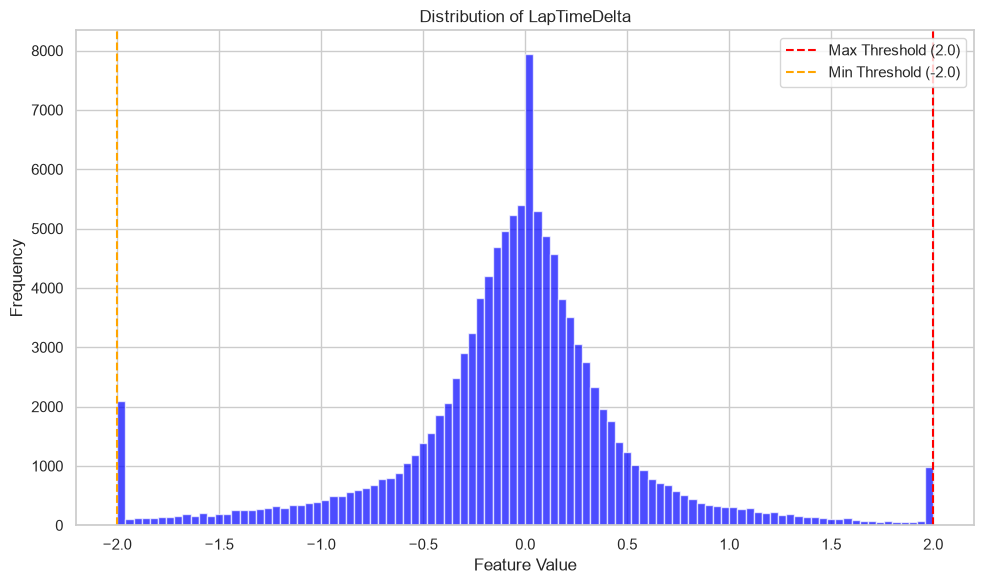

Feature Statistics: count    115725.000000
mean          4.264327
std           3.526001
min           0.002000
25%           1.255000
50%           2.831000
75%           7.496000
max          10.000000
Name: Relative_Gap, dtype: float64
Extreme Relative_Gap values (> 10 or < 0): 0 rows


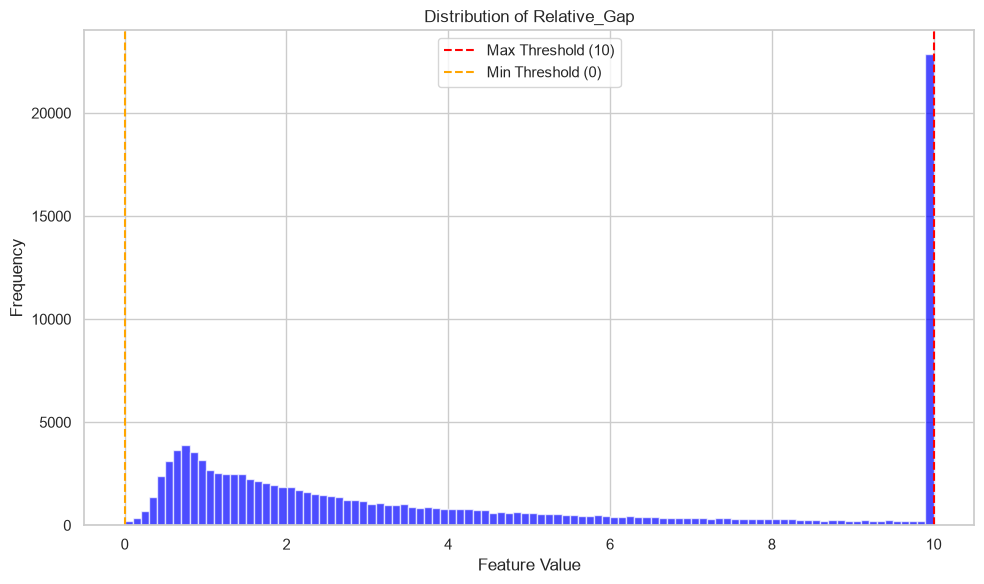

In [65]:
# A small check on numerical features to see if they are within reasonable ranges

def check_extreme_values(df, feature, thre_min=5, thre_max=5, save_path=None):
    print(f"Feature Statistics: {df[feature].describe()}")
    extreme_deltas = df[(df[feature] > thre_max) | (df[feature] < thre_min)]
    print(f"Extreme {feature} values (> {thre_max} or < {thre_min}): {len(extreme_deltas)} rows")

    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.hist(df[feature], bins=100, color='blue', alpha=0.7)
    # add vertical lines for thresholds
    plt.axvline(x=thre_max, color='red', linestyle='--', label=f'Max Threshold ({thre_max})')
    plt.axvline(x=thre_min, color='orange', linestyle='--', label=f'Min Threshold ({thre_min})')
    
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.title('Distribution of ' + feature)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(preprocessing_plots_dir / save_path, dpi=300)
    plt.show()


check_extreme_values(df_full_eng, 'LapTimeDelta', thre_min=-2.0, thre_max=2.0, save_path="01_lap_time_delta_dist.png")

check_extreme_values(df_full_eng, 'Relative_Gap', thre_min=0, thre_max=10, save_path="02_relative_gap_dist.png")

In [66]:
# Reorder to put target feature at the end for better readability and model training
desired_order = [   'Year', 'Event', 'Driver', 'Team', 'LapNumber',                                     # Basic Info
                    'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest',                      # Lap performance
                    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',                                         # Speed
                    'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife', 'TyreLifeSquared', 'Compound',       # Tyre Strategy
                    'Relative_Gap', 'DRS_Active',                                                       # Relative Gap and DRS
                    'IsSafetyCar', 'IsRedFlag', 'IsVSC','IsPitClosed', 'IsSCEnding',                    # Track Status
                    'AirTemp', 'TrackTemp', 'Rainfall',                                                 # Weather Conditions
                    'LapTimeSeconds','LapTimeDelta',                                                    # Target Feature
]

 
df_no_extreme = reorder_columns(df_full_eng, desired_order)
df_no_extreme.columns

Index(['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'Sector1Time',
       'Sector2Time', 'Sector3Time', 'IsPersonalBest', 'SpeedI1', 'SpeedI2',
       'SpeedFL', 'SpeedST', 'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife',
       'TyreLifeSquared', 'Compound', 'Relative_Gap', 'DRS_Active',
       'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',
       'AirTemp', 'TrackTemp', 'Rainfall', 'LapTimeSeconds', 'LapTimeDelta'],
      dtype='object')

# Preprocessor - Fit and Transform of Split Data

In [67]:
# Feature Groups / Categorization for Preprocessing

# Embedding features
# categorical features with many unique values, suitable for embedding layers in neural networks
embedding_features = ['Year', 'Event', 'Driver', 'Team']          

# One-hot encoding features
# categorical features with a limited number of unique values, suitable for one-hot encoding
onehot_features = ['Compound']                   

# Robust scaling features
# numerical features that may have outliers, suitable for robust scaling
robust_features = [
    'LapTimeDelta', 'LapTimeSeconds', 
    'Sector1Time', 'Sector2Time', 'Sector3Time',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
    'Relative_Gap',
    'TrackTemp', 'AirTemp'
]

# Min-max scaling features
# numerical features that are bounded and can be scaled to a specific range, suitable for min-max scaling
minmax_features = [
    'LapNumber', 'Stint', 'Stint_Age', 
    'TyreLife', 'TyreLifeSquared'
]

# Boolean features
# binary features that represent true/false conditions, suitable for boolean representation
bool_features = [
    'IsPersonalBest', 'FreshTyre', 'DRS_Active',
    'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',
    'Rainfall',
]

In [68]:
# Make sure to validate and cast the feature types before passing into F1Preprocessor

def validate_and_cast_feature_types(df, 
                                   embedding_cols=embedding_features, 
                                   onehot_cols=onehot_features, 
                                   robust_cols=robust_features, 
                                   minmax_cols=minmax_features, 
                                   bool_cols=bool_features):
    """
    Validates and casts DataFrame columns to their expected data types 
    before passing into F1Preprocessor.
    """
    df = df.copy()
    
    # 1. Cast Boolean features to explicit bool (True / False)
    for col in bool_cols:
        if col in df.columns:
            # fillna(0) then cast to bool: 1/1.0/True -> True, 0/0.0/False/NaN -> False
            df[col] = df[col].fillna(0).astype(bool)
            
    # 2. Cast Numeric (Robust & MinMax) features to float64
    numeric_cols = robust_cols + minmax_cols
    for col in numeric_cols:
        if col in df.columns:
            # pd.to_numeric with errors='coerce' will convert invalid parsing to NaN, then we cast to float64
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')
            
    # 3. Cast Categorical (Embedding & One-Hot) features to string/object
    cat_cols = embedding_cols + onehot_cols
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)
            
    return df

df_no_extreme = validate_and_cast_feature_types(df_no_extreme)
print(df_no_extreme.dtypes)


Year                object
Event               object
Driver              object
Team                object
LapNumber          float64
Sector1Time        float64
Sector2Time        float64
Sector3Time        float64
IsPersonalBest        bool
SpeedI1            float64
SpeedI2            float64
SpeedFL            float64
SpeedST            float64
Stint              float64
Stint_Age          float64
FreshTyre             bool
TyreLife           float64
TyreLifeSquared    float64
Compound            object
Relative_Gap       float64
DRS_Active            bool
IsSafetyCar           bool
IsRedFlag             bool
IsVSC                 bool
IsPitClosed           bool
IsSCEnding            bool
AirTemp            float64
TrackTemp          float64
Rainfall              bool
LapTimeSeconds     float64
LapTimeDelta       float64
dtype: object


C:\Users\Bevis\AppData\Local\Temp\ipykernel_19136\3765063751.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(0).astype(bool)


In [69]:
# Preprocessor Class for F1 Data

class F1Preprocessor:
    def __init__(self, embedding_cols=embedding_features,
                       onehot_cols=onehot_features,
                       robust_cols=robust_features,
                       minmax_cols=minmax_features,
                       bool_cols=bool_features):
        # Initialize the F1Preprocessor with specified feature groups
        self.embedding_cols = embedding_cols
        self.onehot_cols = onehot_cols
        self.robust_cols = robust_cols
        self.minmax_cols = minmax_cols
        self.bool_cols = bool_cols

        # Initialize the encoders and scalers
        self.label_encoders = {}
        self.onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        self.robust_scaler = RobustScaler()
        self.minmax_scaler = MinMaxScaler()

        # Initialize lists to keep track of valid columns for each transformation
        self.valid_robust = []
        self.valid_minmax = []
        self.valid_onehot = []
        self.feature_names_out = None

    def fit(self, df):
        df = df.copy()
        
        # 1. Fit Embeddings (1-indexed, 0 is saved for <UNK>)
        for col in self.embedding_cols:
            if col in df.columns:
                unique = sorted(df[col].dropna().unique())
                self.label_encoders[col] = {val: i + 1 for i, val in enumerate(unique)}
        
        # 2. Fit One-Hot 
        self.valid_onehot = [c for c in self.onehot_cols if c in df.columns]
        if self.valid_onehot:
            self.onehot_encoder.fit(df[self.valid_onehot].fillna('missing'))
        
        # 3. Fit Scalers (Robust & MinMax)
        self.valid_robust = [c for c in self.robust_cols if c in df.columns]
        if self.valid_robust:
            self.robust_scaler.fit(df[self.valid_robust].fillna(0))
            
        self.valid_minmax = [c for c in self.minmax_cols if c in df.columns]
        if self.valid_minmax:
            self.minmax_scaler.fit(df[self.valid_minmax].fillna(0))
        
        # 4. Create Feature Names
        self._build_feature_names(df)
        return self

    # Build the output feature names after transformation
    def _build_feature_names(self, df):
        self.feature_names_out = []
        
        for col in df.columns:
            if col in self.embedding_cols:
                self.feature_names_out.append(col)
            
            elif col in self.onehot_cols and col in self.valid_onehot:
                oh_names = self.onehot_encoder.get_feature_names_out([col])
                self.feature_names_out.extend(oh_names)
            
            elif col in self.robust_cols or col in self.minmax_cols or col in self.bool_cols:
                self.feature_names_out.append(col)
        
        return self.feature_names_out

    def transform(self, df):
        df = df.copy()
        processed = []
        
        # 1. Transform One-Hot Encoded Features
        oh_transformed = {}
        if self.valid_onehot:
            oh_array = self.onehot_encoder.transform(df[self.valid_onehot].fillna('missing'))
            # Split the transformed array back into individual columns
            start_idx = 0
            for col in self.valid_onehot:
                cats_len = len(self.onehot_encoder.categories_[self.valid_onehot.index(col)])
                oh_transformed[col] = oh_array[:, start_idx:start_idx + cats_len]
                start_idx += cats_len

        # 2. Transform Robust Scaled Features
        robust_transformed = {}
        if self.valid_robust:
            rob_array = self.robust_scaler.transform(df[self.valid_robust].fillna(0))
            for i, col in enumerate(self.valid_robust):
                robust_transformed[col] = rob_array[:, i:i+1]

        # 3. Transform Min-Max Scaled Features
        minmax_transformed = {}
        if self.valid_minmax:
            mm_array = self.minmax_scaler.transform(df[self.valid_minmax].fillna(0))
            for i, col in enumerate(self.valid_minmax):
                minmax_transformed[col] = mm_array[:, i:i+1]

        # 4. Combine Features in Original Column Order
        for col in df.columns:
            if col in self.embedding_cols:
                # Map categorical values to their corresponding integer indices, 
                # fill NaN with 0 (for <UNK>), and reshape to a column vector
                vals = df[col].map(self.label_encoders.get(col, {})).fillna(0).astype(int).values.reshape(-1, 1)
                processed.append(vals)
                
            elif col in self.onehot_cols and col in oh_transformed:
                processed.append(oh_transformed[col])
                
            elif col in self.robust_cols and col in robust_transformed:
                processed.append(robust_transformed[col])
                
            elif col in self.minmax_cols and col in minmax_transformed:
                processed.append(minmax_transformed[col])
                
            elif col in self.bool_cols:
                vals = df[col].fillna(0).astype(int).values.reshape(-1, 1)
                processed.append(vals)
        
        return np.hstack(processed)

    def get_feature_names(self):
        return self.feature_names_out.copy()

    def inverse_transform_field(self, scaled_values, col_name):
        # Make sure the input is 2D shape (N, 1)
        scaled_values_2d = np.array(scaled_values).reshape(-1, 1)
        
        # Case A: The column belongs to Robust Scaler
        if col_name in self.valid_robust:
            col_idx = self.valid_robust.index(col_name)
            center = self.robust_scaler.center_[col_idx]
            scale = self.robust_scaler.scale_[col_idx]
            # RobustScaler inverse formula: original = scaled * scale + center
            return (scaled_values_2d * scale + center).flatten()
            
        # Case B: The column belongs to MinMax Scaler
        elif col_name in self.valid_minmax:
            col_idx = self.valid_minmax.index(col_name)
            min_val = self.minmax_scaler.data_min_[col_idx]
            max_val = self.minmax_scaler.data_max_[col_idx]
            # MinMaxScaler inverse transform: original = scaled * (max - min) + min
            return (scaled_values_2d * (max_val - min_val) + min_val).flatten()
            
        else:
            raise ValueError(f"Column '{col_name}' is not in either robust_cols or minmax_cols!")

In [70]:
# Data split

# Sort by Year, Event, Driver, and LapNumber to ensure proper time-series continuity before splitting
df_no_extreme = df_no_extreme.sort_values(by=['Year', 'Event', 'Driver', 'LapNumber']).reset_index(drop=True)

df_no_extreme['Year'] = df_no_extreme['Year'].astype(str)

train_df = df_no_extreme[df_no_extreme['Year'].isin(['2020', '2021', '2022', '2023'])].copy()
val_df   = df_no_extreme[df_no_extreme['Year'] == '2024'].copy()
test_df  = df_no_extreme[df_no_extreme['Year'] >= '2025'].copy()

print(f"Train shape: {train_df.shape}, Val shape: {val_df.shape}, Test shape: {test_df.shape}")

Train shape: (72520, 31), Val shape: (22344, 31), Test shape: (20861, 31)


In [71]:
# Fit the preprocessor on the training data and transform all datasets
preprocessor = F1Preprocessor()
preprocessor.fit(train_df)                    # Only fit on train

X_train = preprocessor.transform(train_df)
X_val   = preprocessor.transform(val_df)
X_test  = preprocessor.transform(test_df)

# Check for NaN and Inf values in the transformed datasets
print(f"Training data - Any NaN: {np.isnan(X_train).any()}, Any Inf: {np.isinf(X_train).any()}")
print(f"Validation data - Any NaN: {np.isnan(X_val).any()}, Any Inf: {np.isinf(X_val).any()}")
print(f"Test data - Any NaN: {np.isnan(X_test).any()}, Any Inf: {np.isinf(X_test).any()}")

print(f"feature_names_out: {preprocessor.get_feature_names()}")

Training data - Any NaN: False, Any Inf: False
Validation data - Any NaN: False, Any Inf: False
Test data - Any NaN: False, Any Inf: False
feature_names_out: ['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife', 'TyreLifeSquared', 'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET', 'Relative_Gap', 'DRS_Active', 'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding', 'AirTemp', 'TrackTemp', 'Rainfall', 'LapTimeSeconds', 'LapTimeDelta']


           Feature Train_Min Train_Max  Transformed_Min  Transformed_Max
0      Sector1Time    16.632    46.151        -1.465178         2.279462
1      Sector2Time    17.606    54.277        -1.736130         2.502312
2      Sector3Time    16.396    46.438        -1.370050         2.944315
3          SpeedI1      95.0     349.0        -3.214286         1.321429
4          SpeedI2     115.0     341.0        -2.764706         1.666667
5          SpeedFL     140.0     348.0        -3.045455         1.681818
6          SpeedST     186.0     361.0        -6.000000         3.210526
7     Relative_Gap     0.002      10.0        -0.439752         1.047106
8          AirTemp       8.9      37.2        -2.119403         2.104478
9        TrackTemp      13.8      57.5        -1.590909         1.719697
10  LapTimeSeconds    56.319   129.869        -1.764343         2.538148
11    LapTimeDelta      -2.0       2.0        -4.055215         4.124744


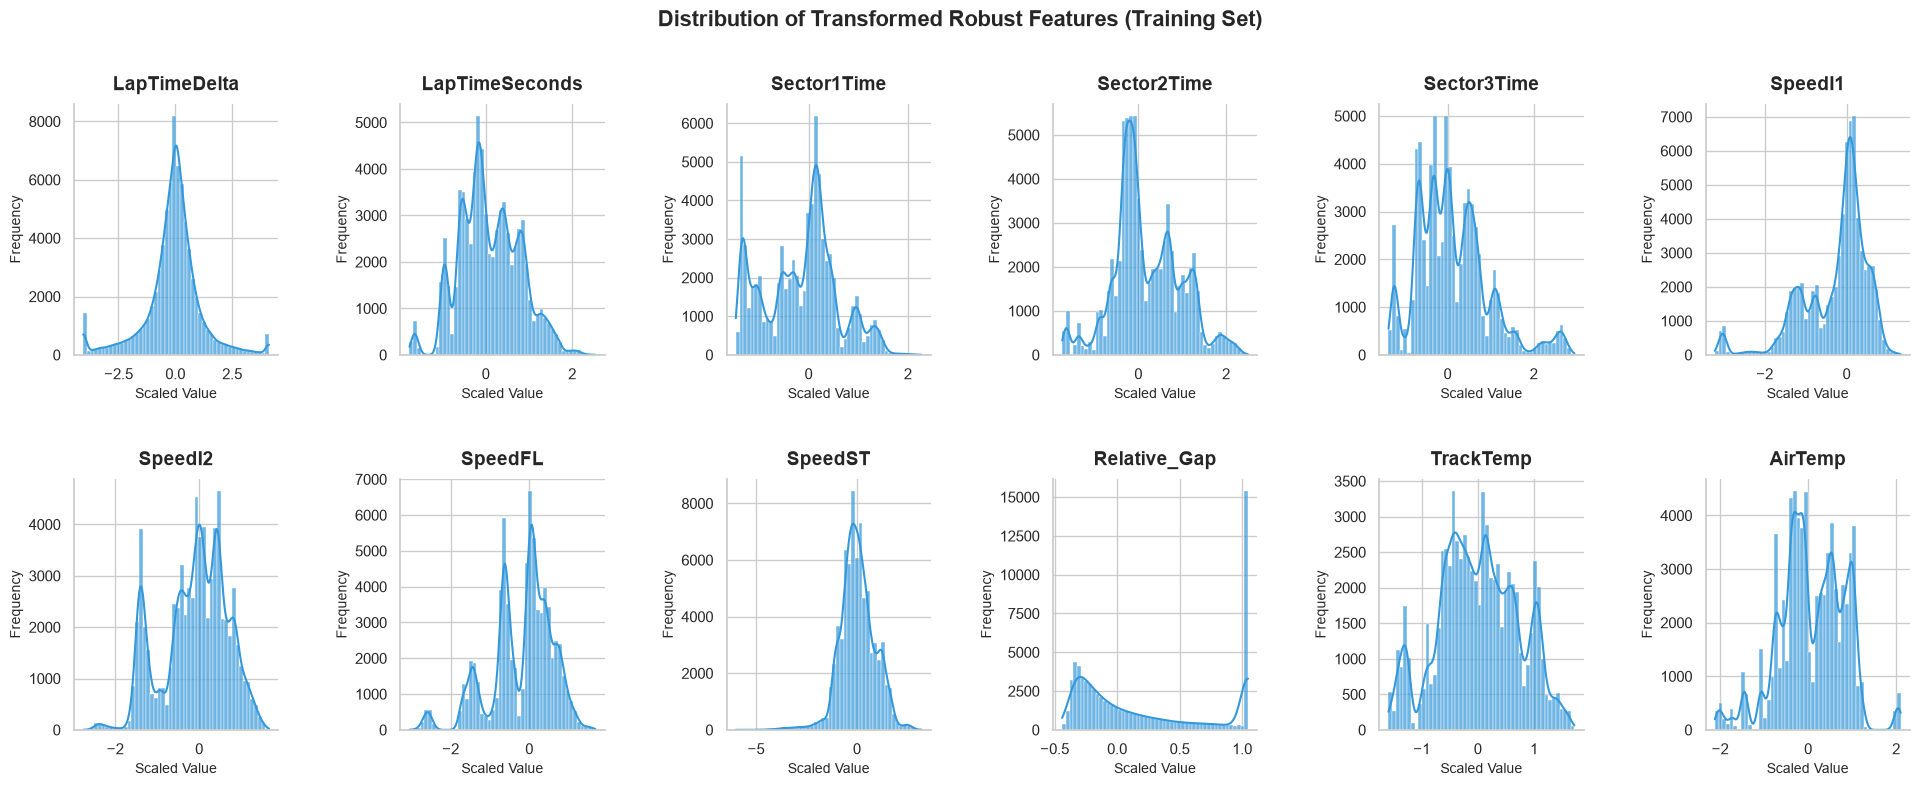

In [120]:
# Compare the max and min of features in X_train and train_df to ensure scaling is correct

feature_names = preprocessor.get_feature_names()

df_feature_stats = pd.DataFrame({
    'Feature': feature_names,
    'Train_Min': [train_df[col].min() if col in train_df.columns else np.nan for col in feature_names],
    'Train_Max': [train_df[col].max() if col in train_df.columns else np.nan for col in feature_names],
    'Transformed_Min': [X_train[:, i].min() for i in range(X_train.shape[1])],
    'Transformed_Max': [X_train[:, i].max() for i in range(X_train.shape[1])]
})

# only show the robust features for comparison
robust_feature_stats = df_feature_stats[df_feature_stats['Feature'].isin(robust_features)].reset_index(drop=True)
print(robust_feature_stats)


# check the distribution of the transformed features to ensure they are within expected ranges
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 8))  

for i, feature in enumerate(robust_features):
    if feature in feature_names:
        idx = feature_names.index(feature)
        ax = plt.subplot(2, 6, i + 1)
        sns.histplot(X_train[:, idx], bins=50, kde=True, 
                     color='#3498db', edgecolor='white', alpha=0.7, ax=ax)
        ax.set_title(f'{feature}', fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Scaled Value', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        sns.despine()
plt.tight_layout(pad=3.0)
plt.suptitle("Distribution of Transformed Robust Features (Training Set)", fontsize=16, fontweight='bold', y=1.02)
plt.savefig(preprocessing_plots_dir / "03_Transformed_Robust_Features_Distribution.png", dpi=300)
plt.show()

# Sequence Dataset - Create Sliding Window

In [73]:
# Create a sequence dataset (sliding window) class

class F1SequenceDataset(Dataset):
    def __init__(self, data_matrix, cat_idx, cont_idx, target_idx,
                 unknown_cont_rel_idx, seq_len=10, forecast_len=5, meta_idx=[0, 1, 2], verbose=True):
        """
        target_idx: Absolute index of target in data_matrix.
        unknown_cont_rel_idx: List of relative indices inside cont_idx that need to be masked.
                              e.g., [0, 1, 2, 8] if sector times and target are at these positions in cont_idx.
        """
        self.data = np.array(data_matrix)
        self.seq_len = seq_len
        self.forecast_len = forecast_len

        self.cat_idx = cat_idx
        self.cont_idx = cont_idx
        self.target_idx = target_idx
        self.unknown_cont_rel_idx = unknown_cont_rel_idx

        self.meta_idx = meta_idx
        self.indices = self._build_valid_indices()

        if verbose:
            print("\n" + "="*50)
            print("  [F1SequenceDataset Initialization Log]")
            print("="*50)
            print(f"Total sequence window length: {self.seq_len + self.forecast_len} (History: {self.seq_len}, Future: {self.forecast_len})")
            print(f"Valid sequences generated: {len(self.indices)}")
            print(f"Masked Relative Continuous Indices in x_cont_fut: {self.unknown_cont_rel_idx}")
            print("="*50 + "\n")

    def _build_valid_indices(self):
        valid = []
        total_window_len = self.seq_len + self.forecast_len
        n = len(self.data) - total_window_len + 1

        for i in range(n):
            window_meta = self.data[i : i + total_window_len, self.meta_idx]
            if np.all(window_meta == window_meta[0]):
                valid.append(i)

        return np.array(valid)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + self.seq_len

        # 1. Historical sequence (Encoder Input)
        input_seq = self.data[start:end]
        x_cat = torch.tensor(input_seq[:, self.cat_idx], dtype=torch.long)
        x_cont = torch.tensor(input_seq[:, self.cont_idx], dtype=torch.float32)

        # 2. Future sequence (Decoder Input)
        future_seq = self.data[end : end + self.forecast_len]
        x_cat_fut = torch.tensor(future_seq[:, self.cat_idx], dtype=torch.long)
        x_cont_fut = torch.tensor(future_seq[:, self.cont_idx], dtype=torch.float32)

        # 3. Mask the unknown continuous features in the future sequence (e.g., sector times and target)
        x_cont_fut[:, self.unknown_cont_rel_idx] = 0.0

        # 4. Ground truth target Y
        y = torch.tensor(future_seq[:, self.target_idx], dtype=torch.float32).unsqueeze(-1)

        return x_cat, x_cont, x_cat_fut, x_cont_fut, y

In [74]:
# Get indexes for categorical, continuous, and target features

# Get the feature names array from the preprocessor
target_feature = 'LapTimeDelta'
feature_names = preprocessor.get_feature_names()
print("Feature names from preprocessor:", feature_names)
print(f"Total number of features after preprocessing: {len(feature_names)}")

# Get indexes for categorical, continuous, and target features
cat_idx    = [feature_names.index(col) for col in embedding_features]
cont_idx   = [i for i, name in enumerate(feature_names) if name not in embedding_features]
target_idx = feature_names.index(target_feature)

print(f"Categorical feature indexes {len(cat_idx)}: {cat_idx}")
print(f"Continuous feature indexes {len(cont_idx)}: {cont_idx}")
print(f"Target feature index: {target_idx}")

# Identify the relative indexes of continuous features that need to be masked in the future sequence (e.g., sector times and target)
unknown_fut_cols = [
    'LapTimeDelta', 'LapTimeSeconds', 
    'Sector1Time', 'Sector2Time', 'Sector3Time',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST'
]
cont_feature_names = [feature_names[i] for i in cont_idx]
unknown_cont_rel_idx = [
    i for i, col in enumerate(cont_feature_names) if col in unknown_fut_cols
]

print(f"Relative indexes of continuous features to be masked in future sequence: {unknown_cont_rel_idx}")

Feature names from preprocessor: ['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife', 'TyreLifeSquared', 'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET', 'Relative_Gap', 'DRS_Active', 'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding', 'AirTemp', 'TrackTemp', 'Rainfall', 'LapTimeSeconds', 'LapTimeDelta']
Total number of features after preprocessing: 35
Categorical feature indexes 4: [0, 1, 2, 3]
Continuous feature indexes 31: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
Target feature index: 34
Relative indexes of continuous features to be masked in future sequence: [1, 2, 3, 5, 6, 7, 8, 29, 30]


In [75]:
# Check the Tensor shapes from the F1SequenceDataset and DataLoader

f1_dataset = F1SequenceDataset(
    data_matrix=X_train,
    cat_idx=cat_idx,
    cont_idx=cont_idx,
    target_idx=target_idx,
    unknown_cont_rel_idx=unknown_cont_rel_idx, 
    seq_len=12,
    forecast_len=3,
    meta_idx=[0, 1, 2],     # [Year, Event, Driver]
    verbose=True
)

print(f"Total Valid Sliding Window Sequences: {len(f1_dataset)}")

# Create DataLoader
dataloader = DataLoader(f1_dataset, batch_size=32, shuffle=True)
x_cat_b, x_cont_b, x_cat_fut_b, x_cont_fut_b, y_b = next(iter(dataloader))

# 1. Output the shapes of the tensors to verify correctness
print("\n--- Tensor Shapes Verification ---")
print(f"x_cat_batch shape:     | Expect: (32, {f1_dataset.seq_len}, {len(cat_idx)})  | {x_cat_b.shape}")
print(f"x_cont_batch shape:    | Expect: (32, {f1_dataset.seq_len}, {len(cont_idx)}) | {x_cont_b.shape}")
print(f"x_cat_fut_batch shape: | Expect: (32, {f1_dataset.forecast_len}, {len(cat_idx)})   | {x_cat_fut_b.shape}")
print(f"x_cont_fut_batch shape:| Expect: (32, {f1_dataset.forecast_len}, {len(cont_idx)})  | {x_cont_fut_b.shape}")
print(f"y_batch shape:         | Expect: (32, {f1_dataset.forecast_len}, 1)   | {y_b.shape}")

# 2. Check that the masked continuous features in the future sequence are indeed zeroed out (no leakage)
masked_indices = f1_dataset.unknown_cont_rel_idx
zero_check = (x_cont_fut_b[:, :, masked_indices] == 0.0).all().item()

print(f"Target & Dynamic Feature Masking Check: {'✅ PASSED (No Leakage)' if zero_check else '❌ FAILED (Data Leakage!)'}")


  [F1SequenceDataset Initialization Log]
Total sequence window length: 15 (History: 12, Future: 3)
Valid sequences generated: 50779
Masked Relative Continuous Indices in x_cont_fut: [1, 2, 3, 5, 6, 7, 8, 29, 30]

Total Valid Sliding Window Sequences: 50779

--- Tensor Shapes Verification ---
x_cat_batch shape:     | Expect: (32, 12, 4)  | torch.Size([32, 12, 4])
x_cont_batch shape:    | Expect: (32, 12, 31) | torch.Size([32, 12, 31])
x_cat_fut_batch shape: | Expect: (32, 3, 4)   | torch.Size([32, 3, 4])
x_cont_fut_batch shape:| Expect: (32, 3, 31)  | torch.Size([32, 3, 31])
y_batch shape:         | Expect: (32, 3, 1)   | torch.Size([32, 3, 1])
Target & Dynamic Feature Masking Check: ✅ PASSED (No Leakage)


In [76]:
# Create the datasets for training, validation, and testing with specified sequence and forecast lengths

seq_len = 10        # Number of historical laps to consider for the encoder input
forecast_len = 3    # Number of future laps to predict for the decoder output

# Create the datasets for training, validation, and testing
train_dataset = F1SequenceDataset(
    data_matrix=X_train, 
    cat_idx=cat_idx,
    cont_idx=cont_idx,
    target_idx=target_idx,
    unknown_cont_rel_idx=unknown_cont_rel_idx, 
    seq_len=seq_len,
    forecast_len=forecast_len,
    meta_idx=[0, 1, 2],     # [Year, Event, Driver]
    verbose=True
)

val_dataset = F1SequenceDataset(
    data_matrix=X_val,
    cat_idx=cat_idx,
    cont_idx=cont_idx,
    target_idx=target_idx,
    unknown_cont_rel_idx=unknown_cont_rel_idx,
    seq_len=seq_len,
    forecast_len=forecast_len,
    meta_idx=[0, 1, 2], 
    verbose=True
)

test_dataset = F1SequenceDataset(
    data_matrix=X_test,
    cat_idx=cat_idx,
    cont_idx=cont_idx,
    target_idx=target_idx,
    unknown_cont_rel_idx=unknown_cont_rel_idx,
    seq_len=seq_len,
    forecast_len=forecast_len,
    meta_idx=[0, 1, 2], 
    verbose=True
)


# Create DataLoader
batch_size = 512
num_cpus = os.cpu_count()
num_workers = 0

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    num_workers=num_workers,
    pin_memory=True,
    shuffle=True, 
    drop_last=True)       

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    num_workers=num_workers, 
    pin_memory=True,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    num_workers=num_workers, 
    pin_memory=True,
    shuffle=False
)


  [F1SequenceDataset Initialization Log]
Total sequence window length: 13 (History: 10, Future: 3)
Valid sequences generated: 53842
Masked Relative Continuous Indices in x_cont_fut: [1, 2, 3, 5, 6, 7, 8, 29, 30]


  [F1SequenceDataset Initialization Log]
Total sequence window length: 13 (History: 10, Future: 3)
Valid sequences generated: 16872
Masked Relative Continuous Indices in x_cont_fut: [1, 2, 3, 5, 6, 7, 8, 29, 30]


  [F1SequenceDataset Initialization Log]
Total sequence window length: 13 (History: 10, Future: 3)
Valid sequences generated: 16380
Masked Relative Continuous Indices in x_cont_fut: [1, 2, 3, 5, 6, 7, 8, 29, 30]



# Model - Seq2Seq LSTM model with Teacher Forcing

In [77]:
# Implementing the Seq2Seq model for F1 Lap Time Prediction


class F1LapSeq2Seq(nn.Module):
    def __init__(self, cat_dims, cont_dim, hidden_dim=128, embed_dim=8, 
                 forecast_len=5, num_layers=2, dropout=0.3, target_col_idx=-1):
        super().__init__()

        # Initialize model parameters
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.forecast_len = forecast_len
        self.target_col_idx = target_col_idx   # Relative index of LapTimeDelta inside continuous features
        
        # Embedding layers for categorical features
        self.embeddings = nn.ModuleList([nn.Embedding(d, embed_dim) for d in cat_dims])
        self.total_cat_dim = len(cat_dims) * embed_dim
        self.input_dim = self.total_cat_dim + cont_dim
        
        # LSTM Encoder and Decoder
        self.encoder = nn.LSTM(self.input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.decoder = nn.LSTM(self.input_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.fc = nn.Linear(hidden_dim, 1)      # Fully connected layer to predict LapTimeDelta
        self.dropout = nn.Dropout(dropout)      # Dropout layer for regularization
        
        self.apply(self._init_weights)
    
    # Custom weight initialization for Linear and LSTM layers
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):            # For the fully connected layer
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LSTM):            # For LSTM layers
            for name, param in m.named_parameters():
                if 'weight_hh' in name:
                    nn.init.orthogonal_(param)      # Orthogonal initialization for hidden-to-hidden weights
                elif 'weight_ih' in name:   
                    nn.init.xavier_uniform_(param)  # Xavier uniform initialization for input-to-hidden weights
    
    def forward(self, x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=None, teacher_forcing_ratio=0.5):
        # batch_size = x_cat.size(0)
        
        # === 1. Encoder Stage ===
        # Process categorical embeddings for historical sequence
        cat_embs = [emb(x_cat[:, :, i]) for i, emb in enumerate(self.embeddings)]
        cat_emb = torch.cat(cat_embs, dim=-1)                   # (B, T_in, total_cat_dim)
        x = torch.cat([cat_emb, x_cont], dim=-1)                # (B, T_in, input_dim)
        
        # Pass historical sequence through encoder
        _, (hidden, cell) = self.encoder(x)
        
        # === 2. Decoder Stage ===
        outputs = []
        # Extract the last historical LapTimeDelta value as initial decoder input -> Shape: (B, 1)
        next_val = x_cont[:, -1, self.target_col_idx]
        
        # Autoregressive decoding loop
        for i in range(self.forecast_len):
            step_cat = x_cat_fut[:, i:i+1, :]            # (B, 1, num_cat)
            step_cont = x_cont_fut[:, i:i+1, :].clone()  # (B, 1, num_cont)
            
            # Inject previous predicted (or ground truth) target value into continuous features
            step_cont[:, 0, self.target_col_idx] = next_val
            
            # Embed categorical features for the current forecast step
            step_cat_embs = [emb(step_cat[:, :, j]) for j, emb in enumerate(self.embeddings)]
            step_cat_emb = torch.cat(step_cat_embs, dim=-1)
            
            # Concatenate categorical and continuous features for single-step input
            decoder_input = torch.cat([step_cat_emb, step_cont], dim=-1) # (B, 1, input_dim)
            
            # Decode one step forward using previous hidden/cell states
            out, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
            pred = self.fc(self.dropout(out)) # (B, 1, 1)
            outputs.append(pred)
            
            # Teacher forcing mechanism for next iteration
            if i < self.forecast_len - 1:
                if y_target is not None and random.random() < teacher_forcing_ratio:
                    next_val = y_target[:, i, 0]    # (B, 1) Use ground truth
                else:
                    next_val = pred.view(-1)        # (B, 1) Use model's own prediction
                    
        return torch.cat(outputs, dim=1) # Final prediction shape: (B, forecast_len, 1)

In [78]:
# Test the F1LapSeq2Seq model with dummy data to ensure forward pass and backpropagation work correctly

def test_f1_model_integrity():
    batch_size = 4
    seq_len = 10
    forecast_len = 5
    
    # Vocabulary sizes for [Year, Event, Driver, Team] after Label Encoding
    cat_dims = [5, 25, 20, 10]   
    cont_dim = 28
    hidden_dim = 64
    embed_dim = 8
    target_col_idx = 27  # E.g., index of LapTimeDelta inside cont_features
    
    # Initialize the model
    model = F1LapSeq2Seq(
        cat_dims=cat_dims, 
        cont_dim=cont_dim, 
        hidden_dim=hidden_dim, 
        embed_dim=embed_dim, 
        forecast_len=forecast_len, 
        num_layers=2, 
        dropout=0.3,
        target_col_idx=target_col_idx
    )
    model.train()  # Set the model to training mode

    # === Dummy Data Generation ===
    # Historical features (Used by Encoder)
    x_cat = torch.stack([torch.randint(0, d, (batch_size, seq_len)) for d in cat_dims], dim=-1)
    x_cont = torch.randn(batch_size, seq_len, cont_dim)
    
    # Future features (Used by Decoder) - Sequence length equals forecast_len
    x_cat_fut = torch.stack([torch.randint(0, d, (batch_size, forecast_len)) for d in cat_dims], dim=-1)
    x_cont_fut = torch.randn(batch_size, forecast_len, cont_dim)
    
    # Target values (Y)
    y_target = torch.randn(batch_size, forecast_len, 1)

    print("--- Testing Model Integrity ---")

    # 1. Testing Forward Pass (With Teacher Forcing)
    try:
        output = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=y_target, teacher_forcing_ratio=1.0)
        print(f"✅ Forward Pass (Teacher Forcing) Success! Output Shape: {output.shape}")
        assert output.shape == (batch_size, forecast_len, 1), "Error: Output shape mismatch!"
    except Exception as e:
        print(f"❌ Forward Pass (Teacher Forcing) Failed: {e}")
        return

    # 2. Testing Forward Pass (Inference Mode - Auto-regressive Only)
    try:
        output_inference = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=None, teacher_forcing_ratio=0.0)
        print(f"✅ Forward Pass (Inference Mode) Success! Output Shape: {output_inference.shape}")
        assert output_inference.shape == (batch_size, forecast_len, 1), "Error: Inference output shape mismatch!"
    except Exception as e:
        print(f"❌ Forward Pass (Inference Mode) Failed: {e}")
        return

    # 3. Testing Gradient Backpropagation & Optimization Step
    try:
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.MSELoss()
        
        loss = criterion(output, y_target)
        optimizer.zero_grad()
        loss.backward()
        
        # Verify that gradients are actually calculated (not None)
        has_grad = all(param.grad is not None for param in model.parameters() if param.requires_grad)
        assert has_grad, "Error: Some trainable parameters have no gradients!"
        
        optimizer.step()
        print(f"✅ Gradient Calculation & Backpropagation Success! Loss: {loss.item():.4f}")
    except Exception as e:
        print(f"❌ Backpropagation Failed: {e}")
        return

    print("--- Testing Completed: Model Architecture is 100% Stable ---")

# Execute Test
test_f1_model_integrity()

--- Testing Model Integrity ---
✅ Forward Pass (Teacher Forcing) Success! Output Shape: torch.Size([4, 5, 1])
✅ Forward Pass (Inference Mode) Success! Output Shape: torch.Size([4, 5, 1])
✅ Gradient Calculation & Backpropagation Success! Loss: 1.2937
--- Testing Completed: Model Architecture is 100% Stable ---


# Training a LSTM model

In [79]:
# Main training loop and the Validation function

def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        # Unpack 5 tensors from the DataLoader
        for x_cat, x_cont, x_cat_fut, x_cont_fut, y in val_loader:
            x_cat = x_cat.to(device)
            x_cont = x_cont.to(device)
            x_cat_fut = x_cat_fut.to(device)
            x_cont_fut = x_cont_fut.to(device)
            y = y.to(device)
            
            # Disable Teacher Forcing (ratio=0.0) for validation
            predictions = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=None, teacher_forcing_ratio=0.0)
            
            loss = criterion(predictions, y)
            val_loss += loss.item()
            
    return val_loss / len(val_loader)


def train_f1_model(model, train_loader, val_loader, 
                   epochs=20, initial_tf_ratio=0.5,
                   HuberLoss_delta=1.5, learning_rate=0.0005, weight_decay=0.02, 
                   sche_patience=5, sche_factor=0.6, early_stopping_patience=15,
                   model_save_path=None):
    
    if model_save_path:
        Path(model_save_path).parent.mkdir(parents=True, exist_ok=True)

    history = {'train_loss': [], 'val_loss': []}
    
    # Quick sanity check on Target Y values range
    for _, _, _, _, y in train_loader:
        print(f"Target Y Range: {y.min():.4f} to {y.max():.4f}")
        break

    # Use GPU if available, otherwise fallback to CPU
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Define loss function, optimizer, and learning rate scheduler
    criterion = nn.HuberLoss(delta=HuberLoss_delta)                                                                
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)                                
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=sche_patience, factor=sche_factor) 

    best_val_loss = float('inf')
    counter = 0

    print(f"Starting training on device: {device}\n" + "-"*50)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        
        # Decay Teacher Forcing ratio linearly over epochs
        current_tf_ratio = initial_tf_ratio * (1.0 - (epoch / epochs))
        
        # Unpack 5 tensors from the DataLoader
        for batch_idx, (x_cat, x_cont, x_cat_fut, x_cont_fut, y) in enumerate(train_loader):
            # Move tensors to the appropriate device
            x_cat = x_cat.to(device)
            x_cont = x_cont.to(device)
            x_cat_fut = x_cat_fut.to(device)
            x_cont_fut = x_cont_fut.to(device)
            y_target = y.to(device) 
            
            optimizer.zero_grad()   # Reset gradients
            
            # Forward pass with teacher forcing
            predictions = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=y_target, teacher_forcing_ratio=current_tf_ratio)
            
            loss = criterion(predictions, y_target)
            loss.backward()
            
            # Prevent gradient explosion in LSTMs
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        # Validation step after each epoch
        val_loss = validate(model, val_loader, criterion, device)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        # 1. Update learning rate scheduler based on validation loss
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if new_lr < old_lr:
            print(f"  [LR Reduced] Learning rate dropped from {old_lr:.6f} to {new_lr:.6f}")

        # 2. Early stopping and best model saving logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            if model_save_path:
                torch.save(model.state_dict(), model_save_path)
            counter = 0  # Reset patience counter on improvement
            saved_str = " --> [Model Saved]"
        else:
            counter += 1
            saved_str = f" (No imp. Patience: {counter}/{early_stopping_patience})"

        print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"TF Ratio: {current_tf_ratio:.2f} | "
              f"LR: {new_lr:.6f}{saved_str}")

        # 3. Early Stopping Trigger
        if counter >= early_stopping_patience:
            print("\nEarly stopping triggered. Training stopped.")
            break

    if model_save_path and Path(model_save_path).exists():
        model.load_state_dict(torch.load(model_save_path, map_location=device))
        print(f"Loaded best model weights from {model_save_path}")

    print("\nTraining completed successfully!")

    return {
        "best_model_path": model_save_path,
        "best_val_loss": best_val_loss,
        "model": model,
        "history": history
    }


In [80]:
# Function to diagnose the dataset and model on CPU to ensure no embedding index errors or data issues exist before training on GPU

def diagnose_dataset_and_model(model, dataloader, cat_dims):
    print("--- STARTING DETAILED CPU DIAGNOSIS --- \n")
    
    # 1. Put the model to CPU
    cpu_model = model.cpu()
    cpu_model.eval()
    
    # 2. Extract a single batch from the DataLoader for inspection
    batch = next(iter(dataloader))
    x_cat, x_cont, x_cat_fut, x_cont_fut, y = batch
    
    print(f"Checking Tensor Shapes:")
    print(f" - x_cat shape:     {x_cat.shape}")
    print(f" - x_cat_fut shape: {x_cat_fut.shape}\n")
    
    # 3. Check Categorical Feature Index Boundaries (Embedding Boundary Check)
    num_cat_cols = x_cat.shape[-1]
    has_index_error = False
    
    for i in range(num_cat_cols):
        max_idx_hist = x_cat[..., i].max().item()
        min_idx_hist = x_cat[..., i].min().item()
        max_idx_fut  = x_cat_fut[..., i].max().item()
        min_idx_fut  = x_cat_fut[..., i].min().item()
        
        allowed_dim = cat_dims[i]
        
        print(f"Category Col [{i}] (Expected Embed Size: {allowed_dim}):")
        print(f"  - History Max Index: {max_idx_hist} | Min Index: {min_idx_hist}")
        print(f"  - Future  Max Index: {max_idx_fut} | Min Index: {min_idx_fut}")
        
        # Check for negative indices (e.g., -1 for missing values)
        if min_idx_hist < 0 or min_idx_fut < 0:
            print(f"  ❌ ERROR: Negative index found in Column {i}! nn.Embedding does not support negative indices.")
            has_index_error = True
            
        # Check for indices out of bounds
        if max_idx_hist >= allowed_dim or max_idx_fut >= allowed_dim:
            print(f"  ❌ ERROR: Index Out of Bounds in Column {i}! Max index ({max(max_idx_hist, max_idx_fut)}) >= cat_dims[{i}] ({allowed_dim})")
            has_index_error = True
            
        if not has_index_error and min_idx_hist >= 0 and max(max_idx_hist, max_idx_fut) < allowed_dim:
            print(f"  ✅ OK")
            
    # 4. Check Continuous Feature for NaN / Inf
    if torch.isnan(x_cont).any() or torch.isinf(x_cont).any():
        print("❌ ERROR: NaN or Inf found in x_cont!")
        has_index_error = True
    if torch.isnan(x_cont_fut).any() or torch.isinf(x_cont_fut).any():
        print("❌ ERROR: NaN or Inf found in x_cont_fut!")
        has_index_error = True

    if has_index_error:
        print("\n❌ Diagnosis Failed: Found data discrepancies listed above.")
        return

    # 5. Force Testing on CPU, Capture Exact Traceback
    print("\n Testing Forward Pass on CPU...")
    try:
        with torch.no_grad():
            out = cpu_model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=y, teacher_forcing_ratio=0.5)
            print(f"✅ CPU Forward Pass Successful! Output shape: {out.shape}")
            print("\n CPU Diagnosis Completed: Data and Model are consistent on CPU!")
    except Exception as e:
        print(f"\n❌ CPU Forward Pass Failed with Error:")
        raise e

# Diagnose the dataset and model on CPU to ensure no embedding index errors or data issues exist before training on GPU 
# Prepare Feature Indexes and Dimensions
feature_names = preprocessor.get_feature_names()                                    # Get feature names from preprocessor
cat_cols = ['Year', 'Event', 'Driver', 'Team']                                      # Define categorical features
cat_idx = [feature_names.index(col) for col in cat_cols]                            # Get indexes for categorical features
cat_dims = [len(preprocessor.label_encoders[col])+1 for col in cat_cols]              # Get the number of unique categories for each categorical feature
cont_idx = [i for i, name in enumerate(feature_names) if name not in cat_cols]      # Get indexes for continuous features
cont_dim = len(cont_idx)                                                                   # Get the number of continuous features
  
forecast_len = 3   

model = F1LapSeq2Seq(
    cat_dims=cat_dims,
    cont_dim=cont_dim,
    hidden_dim=32, 
    embed_dim=4, 
    forecast_len=forecast_len,
    num_layers=2, 
    dropout=0.5, 
    target_col_idx=-1
)


diagnose_dataset_and_model(model, train_loader, cat_dims)

--- STARTING DETAILED CPU DIAGNOSIS --- 

Checking Tensor Shapes:
 - x_cat shape:     torch.Size([512, 10, 4])
 - x_cat_fut shape: torch.Size([512, 3, 4])

Category Col [0] (Expected Embed Size: 5):
  - History Max Index: 4 | Min Index: 1
  - Future  Max Index: 4 | Min Index: 1
  ✅ OK
Category Col [1] (Expected Embed Size: 33):
  - History Max Index: 32 | Min Index: 1
  - Future  Max Index: 32 | Min Index: 1
  ✅ OK
Category Col [2] (Expected Embed Size: 34):
  - History Max Index: 33 | Min Index: 1
  - Future  Max Index: 33 | Min Index: 1
  ✅ OK
Category Col [3] (Expected Embed Size: 14):
  - History Max Index: 13 | Min Index: 1
  - Future  Max Index: 13 | Min Index: 1
  ✅ OK

 Testing Forward Pass on CPU...
✅ CPU Forward Pass Successful! Output shape: torch.Size([512, 3, 1])

 CPU Diagnosis Completed: Data and Model are consistent on CPU!


In [81]:
# Train the base model

# Prepare Feature Indexes and Dimensions
feature_names = preprocessor.get_feature_names()                                    # Get feature names from preprocessor
cat_cols = ['Year', 'Event', 'Driver', 'Team']                                      # Define categorical features
cat_idx = [feature_names.index(col) for col in cat_cols]                            # Get indexes for categorical features
cat_dims = [len(preprocessor.label_encoders[col]) + 1 for col in cat_cols]          # Get the number of unique categories for each categorical feature
cont_idx = [i for i, name in enumerate(feature_names) if name not in cat_cols]      # Get indexes for continuous features
cont_dim = len(cont_idx)                                                            # Get the number of continuous features
  
forecast_len = 3   

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Define the model with specified hyperparameters
model = F1LapSeq2Seq(
    cat_dims=cat_dims,
    cont_dim=cont_dim,
    hidden_dim=32, 
    embed_dim=4, 
    forecast_len=forecast_len,
    num_layers=2, 
    dropout=0.5, 
    target_col_idx=-1
)

# Train the model with specified training parameters
model_training_results = train_f1_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    initial_tf_ratio=0.1,
    HuberLoss_delta=0.5,
    learning_rate=0.0001,
    weight_decay=0.2,
    sche_patience=10,
    sche_factor=0.5,
    early_stopping_patience=15,
    model_save_path='./models/base_model.pth'
)

    

Target Y Range: -4.0552 to 4.1247
Starting training on device: cuda
--------------------------------------------------
Epoch [01/100] | Train Loss: 0.3138 | Val Loss: 0.3060 | TF Ratio: 0.10 | LR: 0.000100 --> [Model Saved]
Epoch [02/100] | Train Loss: 0.3119 | Val Loss: 0.3053 | TF Ratio: 0.10 | LR: 0.000100 --> [Model Saved]
Epoch [03/100] | Train Loss: 0.3103 | Val Loss: 0.3045 | TF Ratio: 0.10 | LR: 0.000100 --> [Model Saved]
Epoch [04/100] | Train Loss: 0.3090 | Val Loss: 0.3036 | TF Ratio: 0.10 | LR: 0.000100 --> [Model Saved]
Epoch [05/100] | Train Loss: 0.3077 | Val Loss: 0.3024 | TF Ratio: 0.10 | LR: 0.000100 --> [Model Saved]
Epoch [06/100] | Train Loss: 0.3055 | Val Loss: 0.3008 | TF Ratio: 0.10 | LR: 0.000100 --> [Model Saved]
Epoch [07/100] | Train Loss: 0.3036 | Val Loss: 0.2988 | TF Ratio: 0.09 | LR: 0.000100 --> [Model Saved]
Epoch [08/100] | Train Loss: 0.3002 | Val Loss: 0.2961 | TF Ratio: 0.09 | LR: 0.000100 --> [Model Saved]
Epoch [09/100] | Train Loss: 0.2951 | Val

Saved F1 Seq2Seq Lap Time Predictions plot to: plots\Base_Model\01_base_Train_Predictions.png


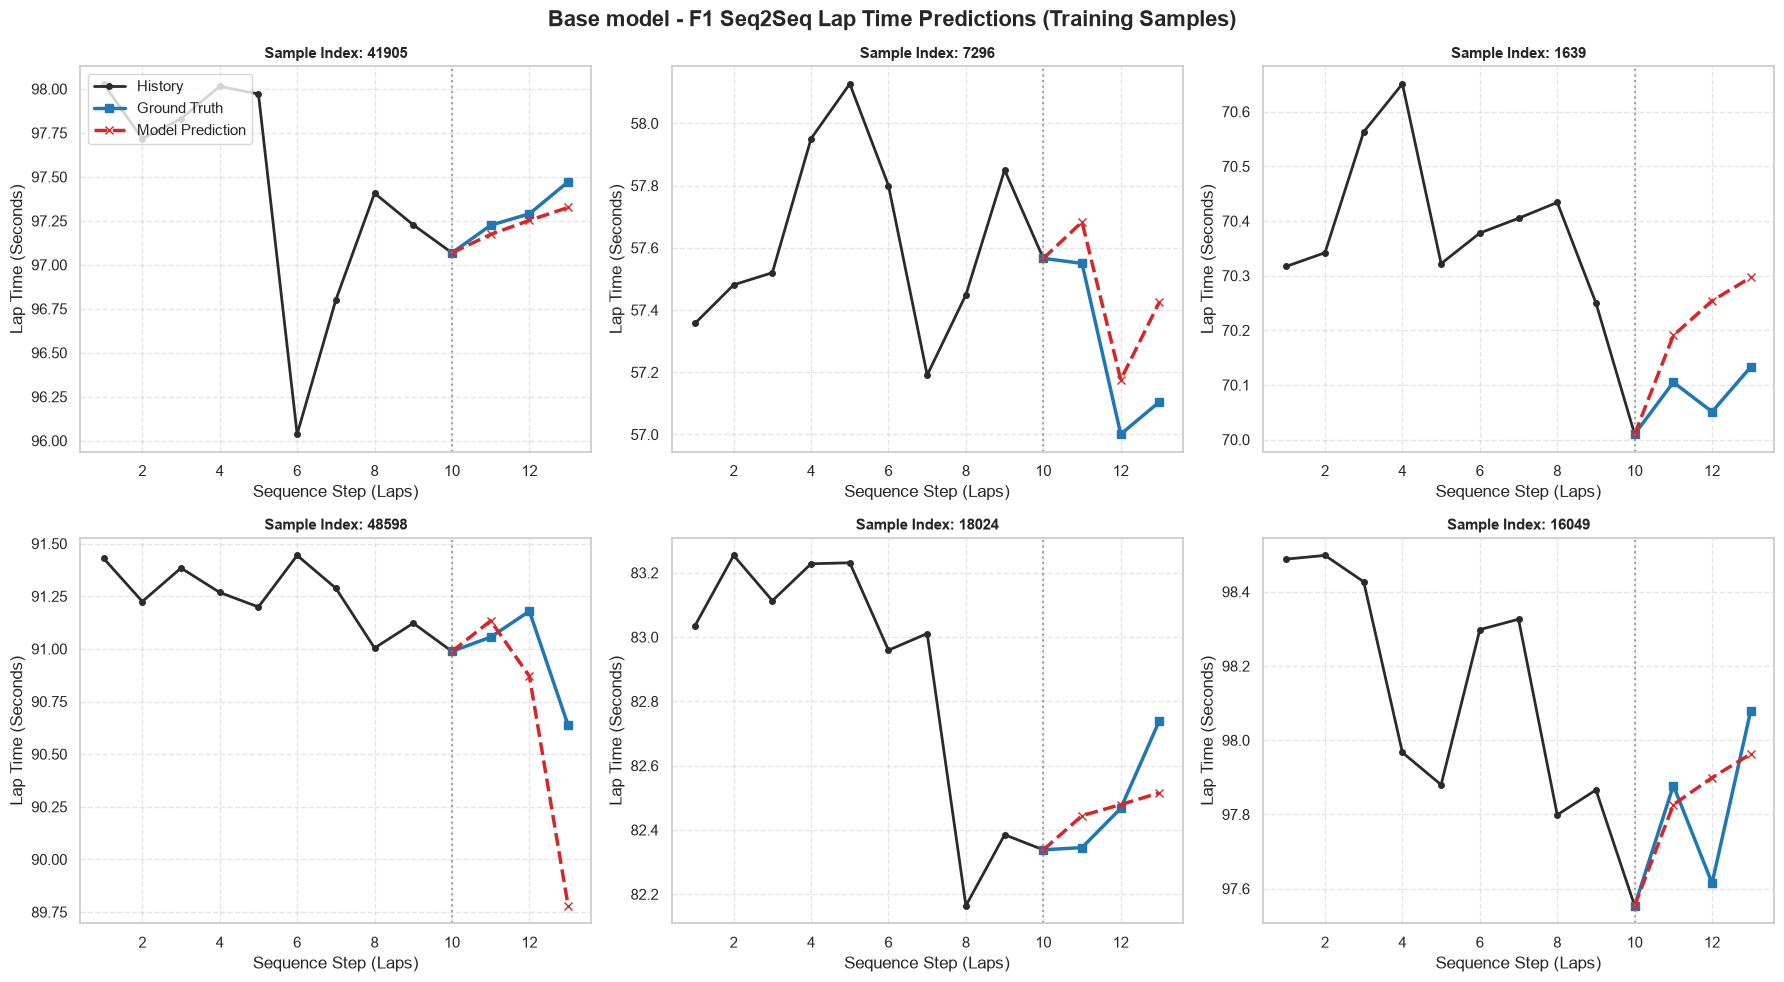

Saved F1 Seq2Seq Lap Time Predictions plot to: plots\Base_Model\02_base_Val_Predictions.png


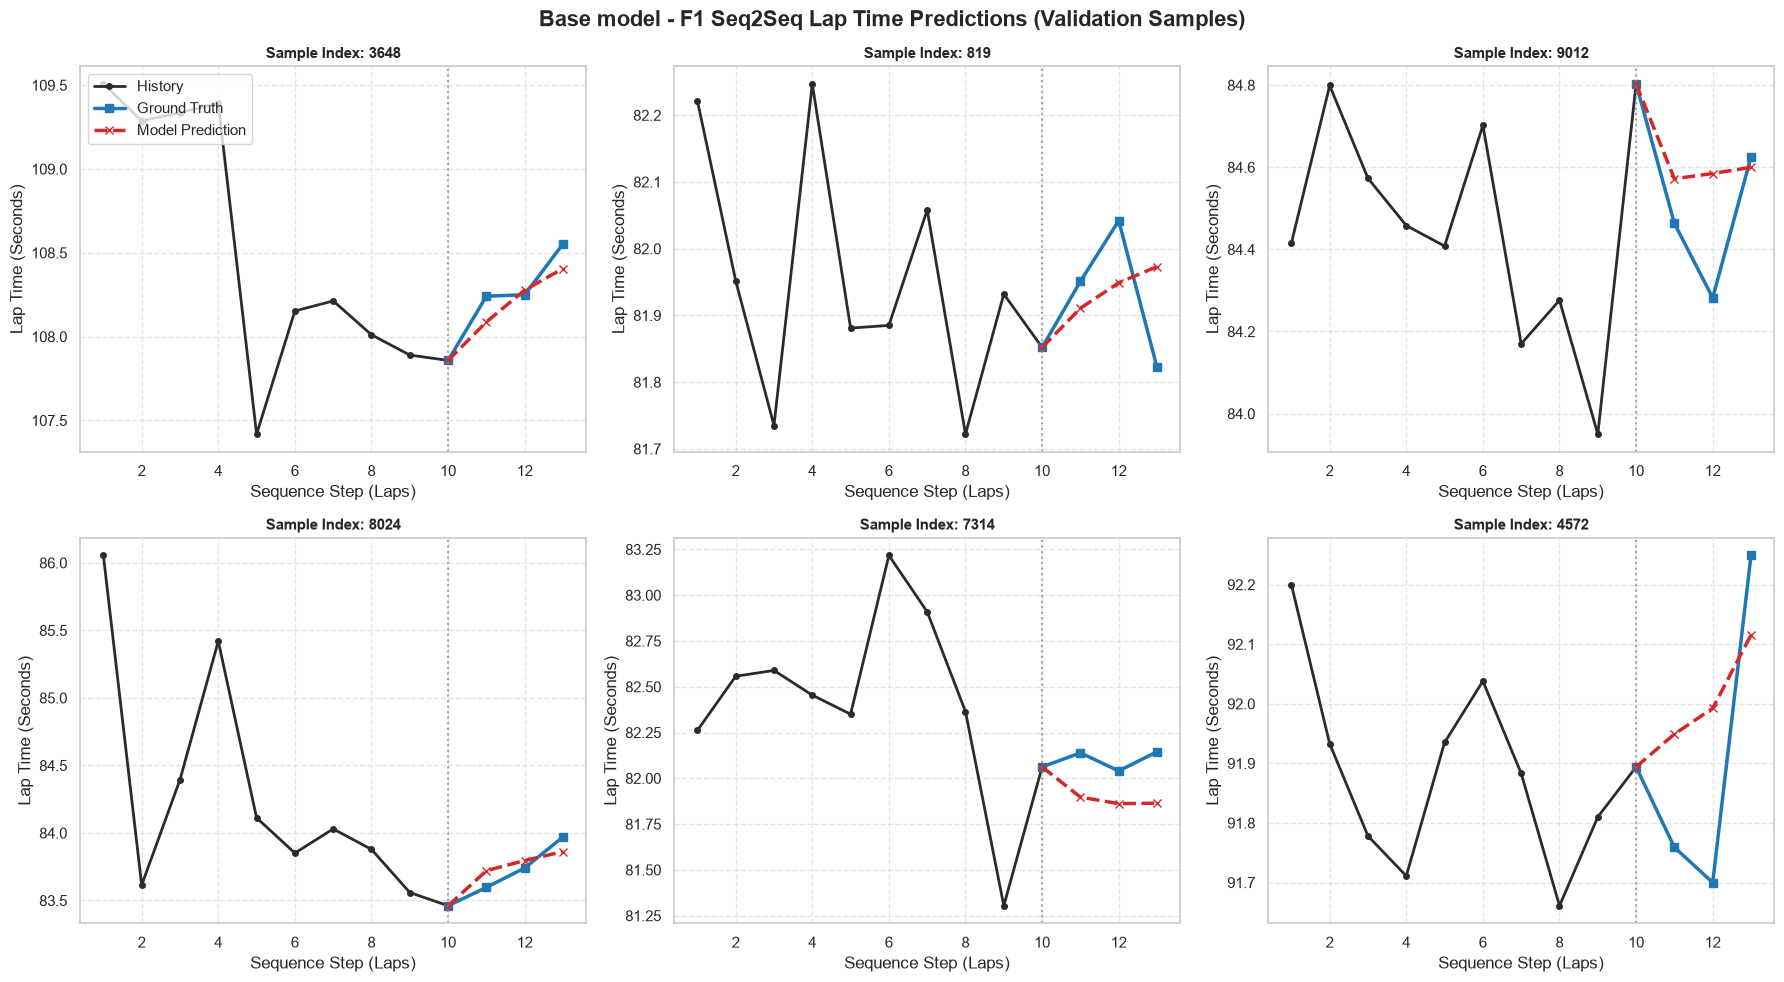

In [86]:
# Visualize the model's predictions on a random selection of validation samples

def plot_f1_predictions_grid(model, dataset, preprocessor, title="F1 Seq2Seq Lap Time Predictions", path=None, device='cuda'):
    """
    Randomly selects 6 samples from the provided dataset and plots the historical lap times, 
    ground truth future lap times, and model predictions in a 2x3 grid.
    """
    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # Sample 6 random indices from the dataset for visualization
    np.random.seed(42)
    random.seed(42)
    
    sample_indices = random.sample(range(len(dataset)), 6)

    for i, idx in enumerate(sample_indices):
        ax = axes[i]
        
        # 1. Extract Data
        x_cat, x_cont, x_cat_fut, x_cont_fut, y = dataset[idx]
        
        x_cat_b = x_cat.unsqueeze(0).to(device)
        x_cont_b = x_cont.unsqueeze(0).to(device)
        x_cat_fut_b = x_cat_fut.unsqueeze(0).to(device)
        x_cont_fut_b = x_cont_fut.unsqueeze(0).to(device)
        
        # 2. Auto-regressive prediction without teacher forcing
        with torch.no_grad():
            pred = model(x_cat_b, x_cont_b, x_cat_fut_b, x_cont_fut_b, y_target=None, teacher_forcing_ratio=0.0)
            
        hist_cont = x_cont.numpy()
        pred_delta_scaled = pred.squeeze().cpu().numpy()
        true_delta_scaled = y.squeeze().cpu().numpy()
        
        # 3. Use the Preprocessor to Inverse Transform the Scaled Predictions and Ground Truth
        pred_delta = preprocessor.inverse_transform_field(pred_delta_scaled, 'LapTimeDelta')
        true_delta = preprocessor.inverse_transform_field(true_delta_scaled, 'LapTimeDelta')
        
        # 4. Extract Historical Lap Times 
        # LapTimeSeconds is the second-to-last column in cont
        hist_laps = preprocessor.inverse_transform_field(hist_cont[:, -2], 'LapTimeSeconds')
        
        # 4. Convert to Absolute Lap Times
        last_known_lap = hist_laps[-1]
        pred_laps = last_known_lap + np.cumsum(pred_delta)
        true_laps = last_known_lap + np.cumsum(true_delta)
        
        # 5. X / Y for plotting
        seq_len = len(hist_laps)
        forecast_len = len(pred_laps)
        
        x_hist = np.arange(1, seq_len + 1)
        x_fut = np.arange(seq_len, seq_len + forecast_len + 1)
        
        y_pred_plot = np.insert(pred_laps, 0, last_known_lap)
        y_true_plot = np.insert(true_laps, 0, last_known_lap)
        
        # 6. Plotting
        ax.plot(x_hist, hist_laps, label='History', color='#2b2b2b', marker='o', linewidth=2, markersize=4)
        ax.plot(x_fut, y_true_plot, label='Ground Truth', color='#1f77b4', marker='s', linewidth=2.5, linestyle='-')
        ax.plot(x_fut, y_pred_plot, label='Model Prediction', color='#d62728', marker='x', linewidth=2.5, linestyle='--')
        
        ax.axvline(x=seq_len, color='gray', linestyle=':', alpha=0.7)
        ax.set_title(f"Sample Index: {idx}", fontsize=11, fontweight='bold')
        ax.set_xlabel("Sequence Step (Laps)")
        ax.set_ylabel("Lap Time (Seconds)")
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 0:
            ax.legend(loc='upper left')

    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    if path:
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Saved F1 Seq2Seq Lap Time Predictions plot to: {path}")
    plt.show()

# Plot predictions on train dataset
plot_f1_predictions_grid(
    model=model_training_results['model'], 
    dataset=train_dataset,
    preprocessor=preprocessor,
    title="Base model - F1 Seq2Seq Lap Time Predictions (Training Samples)",
    path=base_model_plots_dir / "01_base_Train_Predictions.png"
    )

# Plot predictions on validation dataset
plot_f1_predictions_grid(
    model=model_training_results['model'], 
    dataset=val_dataset,
    preprocessor=preprocessor,
    title="Base model - F1 Seq2Seq Lap Time Predictions (Validation Samples)",
    path=base_model_plots_dir / "02_base_Val_Predictions.png"
    )


Saved Forecast Horizon Error Decay plot to: plots\Base_Model\03_base_Val_Forecast_Horizon_Error_Decay.png


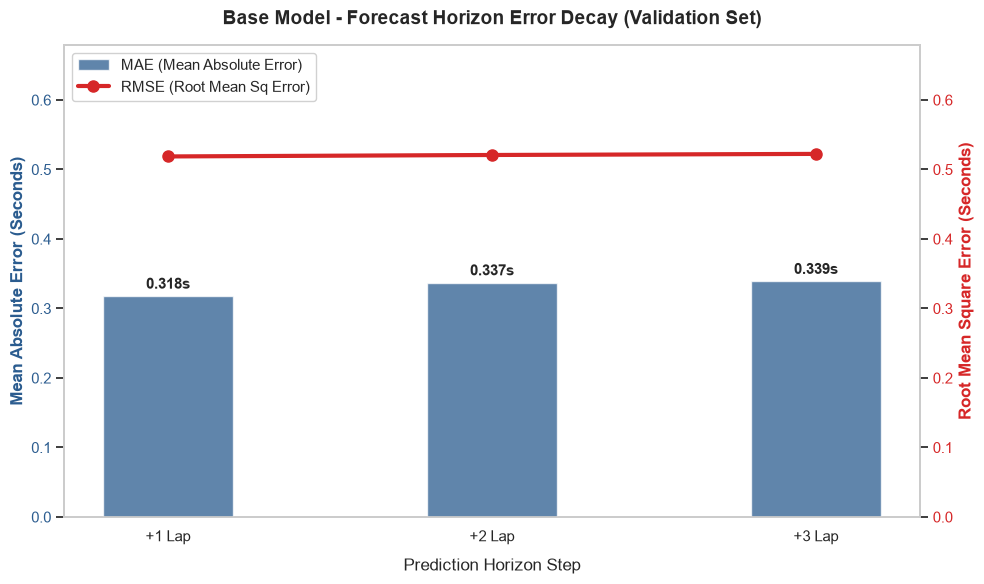

In [114]:
# Visualize the Forecast Horizon Error Decay (MAE & RMSE) for the validation dataset

def plot_forecast_horizon_error_decay(model, dataset, preprocessor, device='cuda', title="Forecast Horizon Error Decay", path=None):
    model.to(device)
    model.eval()
    val_loader = DataLoader(dataset, batch_size=256, shuffle=False)
    
    all_pred_deltas = []
    all_true_deltas = []
    
    # 1. Collect all predictions and true values from the validation set
    with torch.no_grad():
        for batch in val_loader:
            x_cat, x_cont, x_cat_fut, x_cont_fut, y = batch
            
            x_cat = x_cat.to(device)
            x_cont = x_cont.to(device)
            x_cat_fut = x_cat_fut.to(device)
            x_cont_fut = x_cont_fut.to(device)
            
            # Auto-regressive Inference (No Teacher Forcing)
            preds = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=None, teacher_forcing_ratio=0.0)
            
            all_pred_deltas.append(preds.cpu().numpy())
            all_true_deltas.append(y.numpy())
            
    # Concatenate all Batch -> Shape: [Total_Samples, forecast_len]
    pred_scaled = np.vstack(all_pred_deltas).squeeze()
    true_scaled = np.vstack(all_true_deltas).squeeze()
    
    forecast_len = pred_scaled.shape[1]
    
    # 2. Calculate MAE and RMSE for each forecast step
    mae_per_step = []
    rmse_per_step = []
    
    for step in range(forecast_len):
        p_step = preprocessor.inverse_transform_field(pred_scaled[:, step], 'LapTimeDelta')
        t_step = preprocessor.inverse_transform_field(true_scaled[:, step], 'LapTimeDelta')
        
        # Calculate MAE and RMSE
        mae = np.mean(np.abs(p_step - t_step))
        rmse = np.sqrt(np.mean((p_step - t_step) ** 2))
        
        mae_per_step.append(mae)
        rmse_per_step.append(rmse)
        
    # 3. Plotting the Error Decay
    steps_x = [f"+{i+1} Lap" for i in range(forecast_len)]
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # MAE Bar Chart
    bars = ax1.bar(steps_x, mae_per_step, color='#2b5c8f', alpha=0.75, width=0.4, 
                   label='MAE (Mean Absolute Error)', zorder=3)
    ax1.set_ylabel('Mean Absolute Error (Seconds)', fontsize=12, color='#2b5c8f', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2b5c8f')
    ax1.set_ylim(0, max(rmse_per_step) * 1.3)
    ax1.grid(False)
    ax1.set_axisbelow(True)
    
    # Annotate MAE
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}s',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold',
                    zorder=5)

    # RMSE Line Chart
    ax2 = ax1.twinx()
    line = ax2.plot(steps_x, rmse_per_step, color='#d62728', marker='o', linewidth=3, 
                    markersize=8, label='RMSE (Root Mean Sq Error)', zorder=4)
    ax2.set_ylabel('Root Mean Square Error (Seconds)', fontsize=12, color='#d62728', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#d62728')
    ax2.set_ylim(0, max(rmse_per_step) * 1.3)
    ax2.grid(False)

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel("Prediction Horizon Step", fontsize=12, labelpad=10)
    
    # Merge Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Saved Forecast Horizon Error Decay plot to: {path}")
    plt.show()

# Plot the Forecast Horizon Error Decay for the validation dataset using the trained model
plot_forecast_horizon_error_decay(
    model=model_training_results['model'],
    dataset=val_dataset,
    preprocessor=preprocessor,
    device='cuda',
    title="Base Model - Forecast Horizon Error Decay (Validation Set)",
    path=base_model_plots_dir / "03_base_Val_Forecast_Horizon_Error_Decay.png"
)

Saved Residual Distribution Plot to plots\Base_Model\04_base_Val_Error_Residual_Distribution.png


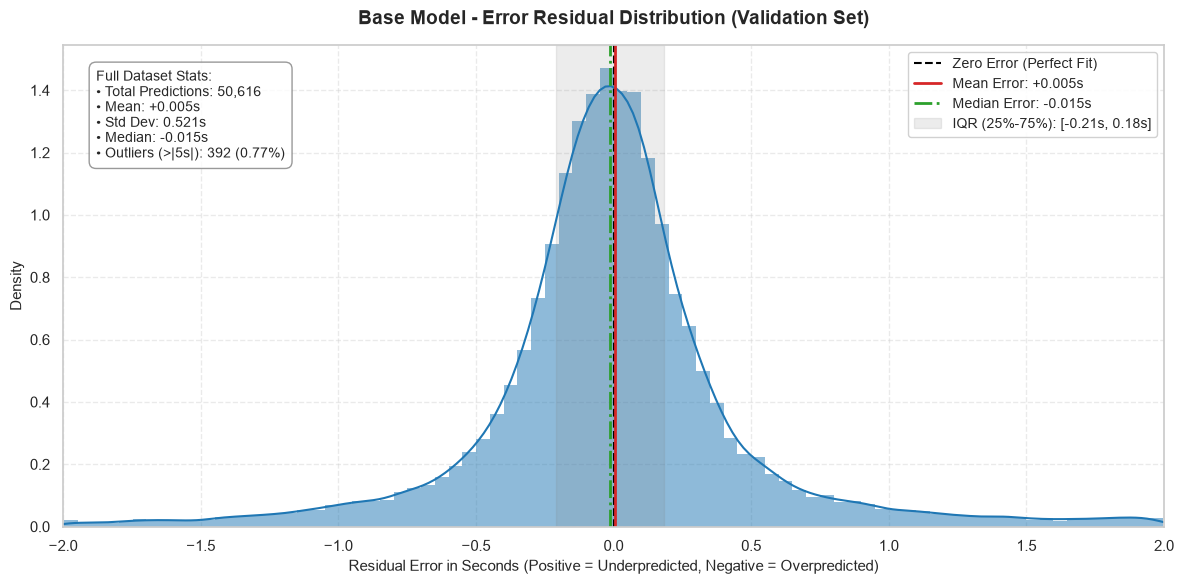

In [103]:
# Visualize the Error Residual Distribution (True - Pred) for the validation dataset

def plot_error_residual_distribution(model, dataset, preprocessor, device='cuda', title="Error Residual Distribution", path=None):
    model.to(device)
    model.eval()
    val_loader = DataLoader(dataset, batch_size=256, shuffle=False)
    
    all_residuals = []
    
    # 1. Extract all predictions and true values from the validation set
    with torch.no_grad():
        for batch in val_loader:
            x_cat, x_cont, x_cat_fut, x_cont_fut, y = batch
            
            x_cat = x_cat.to(device)
            x_cont = x_cont.to(device)
            x_cat_fut = x_cat_fut.to(device)
            x_cont_fut = x_cont_fut.to(device)
            
            preds = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=None, teacher_forcing_ratio=0.0)
            
            p_scaled = preds.cpu().numpy().reshape(-1, 1)
            t_scaled = y.numpy().reshape(-1, 1)
            
            # Inverse transform to seconds using the preprocessor
            p_sec = preprocessor.inverse_transform_field(p_scaled, 'LapTimeDelta')
            t_sec = preprocessor.inverse_transform_field(t_scaled, 'LapTimeDelta')
            
            # Residual = True - Pred
            batch_residuals = t_sec - p_sec
            all_residuals.extend(batch_residuals)
            
    residuals = np.array(all_residuals)
    
    # 2. Compute statistics for the residuals
    mean_res = np.mean(residuals)
    median_res = np.median(residuals)
    std_res = np.std(residuals)
    q25, q75 = np.percentile(residuals, [25, 75])
    
    # 3. Plotting the residual distribution
    plt.figure(figsize=(12, 6))
    
    # For plotting, filter residuals to a reasonable range to avoid extreme outliers skewing the histogram
    plot_mask = (residuals >= -2) & (residuals <= 2)
    filtered_residuals = residuals[plot_mask]
    
    # Histogram + KDE (Kernel Density Estimation)
    sns.histplot(filtered_residuals, kde=True, bins=80, color='#1f77b4', stat="density", alpha=0.5, edgecolor='none')
    
    # Mean, Median, and Zero Line
    plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Error (Perfect Fit)')
    plt.axvline(mean_res, color='#d62728', linestyle='-', linewidth=2, label=f'Mean Error: {mean_res:+.3f}s')
    plt.axvline(median_res, color='#2ca02c', linestyle='-.', linewidth=2, label=f'Median Error: {median_res:+.3f}s')
    
    # IQR (Interquartile Range 25%-75%)
    plt.axvspan(q25, q75, color='gray', alpha=0.15, label=f'IQR (25%-75%): [{q25:.2f}s, {q75:.2f}s]')
    
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Residual Error in Seconds (Positive = Underpredicted, Negative = Overpredicted)", fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.xlim(-2, 2)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
    
    # Add statistical summary text box on the plot
    stats_text = (f"Full Dataset Stats:\n"
                  f"• Total Predictions: {len(residuals):,}\n"
                  f"• Mean: {mean_res:+.3f}s\n"
                  f"• Std Dev: {std_res:.3f}s\n"
                  f"• Median: {median_res:+.3f}s\n"
                  f"• Outliers (>|5s|): {np.sum(~plot_mask):,} ({np.mean(~plot_mask)*100:.2f}%)")
    
    plt.gca().text(0.03, 0.95, stats_text, transform=plt.gca().transAxes,
                   fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Saved Residual Distribution Plot to {path}")
    plt.show()

# plot the Error Residual Distribution for the validation dataset using the trained model
plot_error_residual_distribution(
    model=model_training_results['model'],
    dataset=val_dataset,
    preprocessor=preprocessor,
    device='cuda',
    title="Base Model - Error Residual Distribution (Validation Set)",
    path=base_model_plots_dir / "04_base_Val_Error_Residual_Distribution.png"
)

# Tuning the  (using Optuna)

In [42]:
# Define the Optuna objective function for hyperparameter optimization with a two-stage coarse-to-fine search strategy

def objective(trial, stage=1, best_params_stage1=None, epochs=50):
    # -------------------------------------------------------------------------
    # 1. Coarse-to-Fine Search Space
    # -------------------------------------------------------------------------
    if stage == 1:
        # Tune the core architecture parameters in stage 1
        hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
        num_layers = trial.suggest_int("num_layers", 1, 3)
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        
        # Fixed baseline parameters for Stage 1
        dropout = 0.2
        embed_dim = 4
        weight_decay = 0.01
        HuberLoss_delta = 1.0
    
    elif stage == 2:
        if best_params_stage1 is None:
            raise ValueError("best_params_stage1 must be provided for stage 2.")
            
        # Freeze Stage 1 best parameters
        hidden_dim = best_params_stage1["hidden_dim"]
        num_layers = best_params_stage1["num_layers"]
        learning_rate = best_params_stage1["learning_rate"]
        
        # Fine-tune regularization and loss dynamics
        embed_dim = trial.suggest_int("embed_dim", 2, 8, step=2)
        dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
        weight_decay = trial.suggest_float("weight_decay", 1e-4, 0.3, log=True)
        HuberLoss_delta = trial.suggest_float("HuberLoss_delta", 0.5, 2.0, step=0.5)

    # Fixed training parameters
    sche_patience = 5               # Patience for ReduceLROnPlateau scheduler
    early_stopping_patience = 12    # Patience for early stopping
    initial_tf_ratio = 0.5

    # -------------------------------------------------------------------------
    # 2. Setup Model, Loss, Optimizer, and Scheduler
    # -------------------------------------------------------------------------
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model = F1LapSeq2Seq(
        cat_dims=cat_dims, 
        cont_dim=cont_dim, 
        hidden_dim=hidden_dim, 
        embed_dim=embed_dim, 
        forecast_len=forecast_len,
        num_layers=num_layers,
        dropout=dropout,
        target_col_idx=-1
    ).to(device)

    criterion = nn.HuberLoss(delta=HuberLoss_delta)                                                                                                                
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)                                 
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=sche_patience, factor=0.6) 

    # -------------------------------------------------------------------------
    # 3. Training Loop with Pruning & Early Stopping
    # -------------------------------------------------------------------------
    best_val_loss = float('inf')
    counter = 0

    for epoch in range(epochs):
        model.train()
        current_tf_ratio = initial_tf_ratio * (1.0 - (epoch / epochs))
        
        for x_cat, x_cont, x_cat_fut, x_cont_fut, y in train_loader:
            x_cat, x_cont = x_cat.to(device), x_cont.to(device)
            x_cat_fut, x_cont_fut = x_cat_fut.to(device), x_cont_fut.to(device)
            y_target = y.to(device) 
            
            optimizer.zero_grad()
            predictions = model(x_cat, x_cont, x_cat_fut, x_cont_fut, y_target=y_target, teacher_forcing_ratio=current_tf_ratio)
            loss = criterion(predictions, y_target)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation Step
        val_loss = validate(model, val_loader, criterion, device)
        
        # Report metric to Optuna for automatic pruning
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # LR Scheduler step
        scheduler.step(val_loss)
        
        # Early Stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0  
        else:
            counter += 1

        if counter >= early_stopping_patience:
            break

    return best_val_loss



In [43]:
# Stage 1: Coarse Search

# Define the Optuna pruner
pruner = optuna.pruners.MedianPruner(n_warmup_steps=5)


print("Starting Stage 1 Optimization...")
study_stage1 = optuna.create_study(direction="minimize", pruner=pruner)
study_stage1.optimize(
    lambda trial: objective(trial, stage=1, epochs=30),
    n_trials=20
) 

print("\nStage 1 Best Parameters:", study_stage1.best_params)


[I 2026-08-14 09:43:13,330] A new study created in memory with name: no-name-c223a753-39da-4d24-bdfd-fa322108a8da


Starting Stage 1 Optimization...


[I 2026-08-14 09:45:36,996] Trial 0 finished with value: 0.37065122253967053 and parameters: {'hidden_dim': 32, 'num_layers': 3, 'learning_rate': 0.00018798011664599896}. Best is trial 0 with value: 0.37065122253967053.
[I 2026-08-14 09:47:45,777] Trial 1 finished with value: 0.4072981756744963 and parameters: {'hidden_dim': 64, 'num_layers': 1, 'learning_rate': 3.627313495207502e-05}. Best is trial 0 with value: 0.37065122253967053.
[I 2026-08-14 09:50:01,997] Trial 2 finished with value: 0.4134190105127566 and parameters: {'hidden_dim': 32, 'num_layers': 3, 'learning_rate': 0.0004914180892666005}. Best is trial 0 with value: 0.37065122253967053.
[I 2026-08-14 09:52:14,365] Trial 3 finished with value: 0.37544390378576337 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'learning_rate': 0.00018290955212006452}. Best is trial 0 with value: 0.37065122253967053.
[I 2026-08-14 09:53:42,623] Trial 4 finished with value: 0.3665440059972532 and parameters: {'hidden_dim': 128, 'num_layers'


Stage 1 Best Parameters: {'hidden_dim': 128, 'num_layers': 3, 'learning_rate': 0.0007642470339763624}


In [44]:
# Stage 2: Fine Search

print("\nStarting Stage 2 Optimization...")
study_stage2 = optuna.create_study(direction="minimize", pruner=pruner)
study_stage2.optimize(
    lambda trial: objective(trial, stage=2, best_params_stage1=study_stage1.best_params, epochs=50),
    n_trials=20
)

print("\nStage 2 Best Parameters:", study_stage2.best_params)


[I 2026-08-14 10:06:42,375] A new study created in memory with name: no-name-18c8cee8-523b-4b73-a383-ad58de4cc6f2



Starting Stage 2 Optimization...


[I 2026-08-14 10:08:06,195] Trial 0 finished with value: 0.44473637414701056 and parameters: {'embed_dim': 6, 'dropout': 0.2, 'weight_decay': 0.001486005307536474, 'HuberLoss_delta': 1.5}. Best is trial 0 with value: 0.44473637414701056.
[I 2026-08-14 10:09:51,166] Trial 1 finished with value: 0.238852833256577 and parameters: {'embed_dim': 4, 'dropout': 0.5, 'weight_decay': 0.0013266270599115824, 'HuberLoss_delta': 0.5}. Best is trial 1 with value: 0.238852833256577.
[I 2026-08-14 10:11:14,975] Trial 2 finished with value: 0.36590610941251117 and parameters: {'embed_dim': 8, 'dropout': 0.1, 'weight_decay': 0.018853103408297704, 'HuberLoss_delta': 1.0}. Best is trial 1 with value: 0.238852833256577.
[I 2026-08-14 10:13:06,418] Trial 3 finished with value: 0.4383124293703021 and parameters: {'embed_dim': 2, 'dropout': 0.1, 'weight_decay': 0.18798667212001294, 'HuberLoss_delta': 1.5}. Best is trial 1 with value: 0.238852833256577.
[I 2026-08-14 10:14:34,983] Trial 4 finished with value: 


Stage 2 Best Parameters: {'embed_dim': 4, 'dropout': 0.1, 'weight_decay': 0.004486238652844911, 'HuberLoss_delta': 0.5}


In [82]:
# Final Model Training with Combined Best Parameters

# Merge Stage 1 and Stage 2 best parameters for final model configuration
best_params = {**study_stage1.best_params, **study_stage2.best_params}
print("\nCombined Optimal Hyperparameters:", best_params)


# Define the model with the best hyperparameters found from the Optuna optimization
best_model = F1LapSeq2Seq(
    cat_dims=cat_dims,
    cont_dim=cont_dim,
    hidden_dim=best_params.get("hidden_dim", 32), 
    embed_dim=best_params.get("embed_dim", 4),
    forecast_len=forecast_len,
    num_layers=best_params.get("num_layers", 2),
    dropout=best_params.get("dropout", 0.5),
    target_col_idx=-1
)

# # Train the model with the best training parameters
best_model_training_results = train_f1_model(
    model=best_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    initial_tf_ratio=0.1,
    HuberLoss_delta=best_params.get("HuberLoss_delta", 1.0),
    learning_rate=best_params.get("learning_rate", 0.0001),
    weight_decay=best_params.get("weight_decay", 0.02),
    sche_patience=10,
    sche_factor=0.5,
    early_stopping_patience=15,
    model_save_path='./models/best_model.pth'
)


Combined Optimal Hyperparameters: {'hidden_dim': 128, 'num_layers': 3, 'learning_rate': 0.0007642470339763624, 'embed_dim': 4, 'dropout': 0.1, 'weight_decay': 0.004486238652844911, 'HuberLoss_delta': 0.5}
Target Y Range: -4.0552 to 4.1247
Starting training on device: cuda
--------------------------------------------------
Epoch [01/100] | Train Loss: 0.2835 | Val Loss: 0.2544 | TF Ratio: 0.10 | LR: 0.000764 --> [Model Saved]
Epoch [02/100] | Train Loss: 0.2355 | Val Loss: 0.2448 | TF Ratio: 0.10 | LR: 0.000764 --> [Model Saved]
Epoch [03/100] | Train Loss: 0.2278 | Val Loss: 0.2415 | TF Ratio: 0.10 | LR: 0.000764 --> [Model Saved]
Epoch [04/100] | Train Loss: 0.2234 | Val Loss: 0.2401 | TF Ratio: 0.10 | LR: 0.000764 --> [Model Saved]
Epoch [05/100] | Train Loss: 0.2222 | Val Loss: 0.2391 | TF Ratio: 0.10 | LR: 0.000764 --> [Model Saved]
Epoch [06/100] | Train Loss: 0.2206 | Val Loss: 0.2389 | TF Ratio: 0.10 | LR: 0.000764 --> [Model Saved]
Epoch [07/100] | Train Loss: 0.2191 | Val Los

Saved F1 Seq2Seq Lap Time Predictions plot to: plots\Best_Model\01_best_Train_Predictions.png


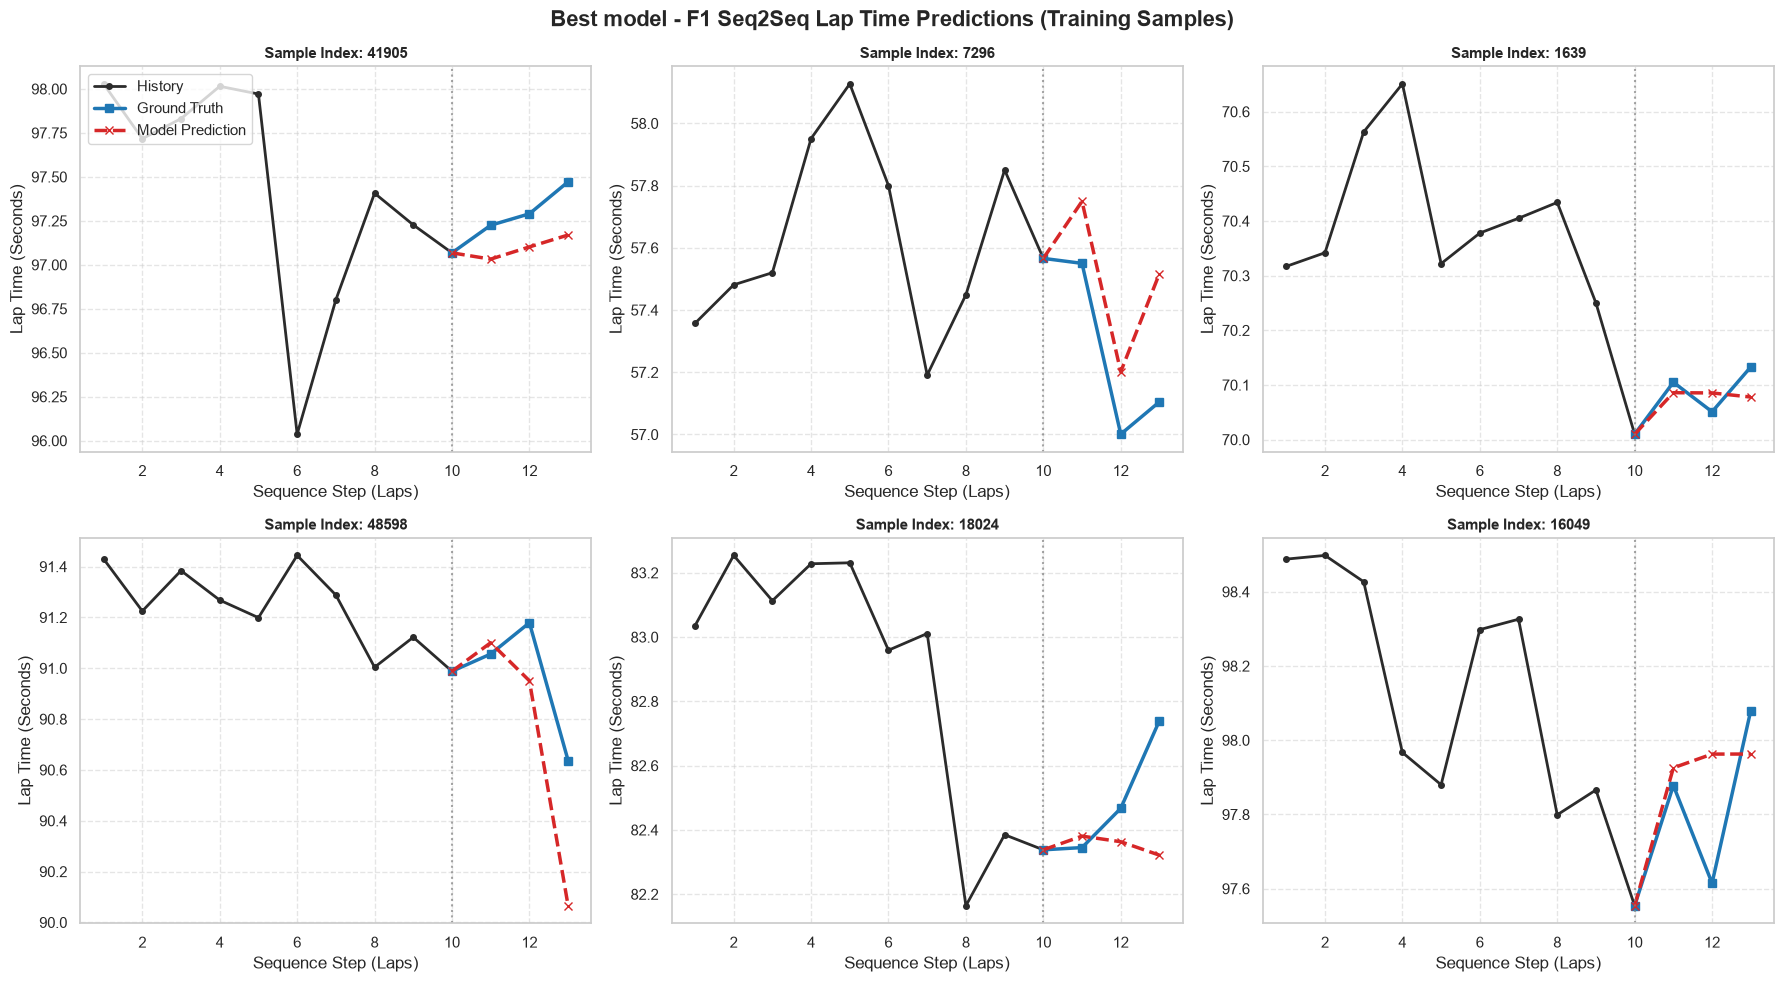

Saved F1 Seq2Seq Lap Time Predictions plot to: plots\Best_Model\02_best_Val_Predictions.png


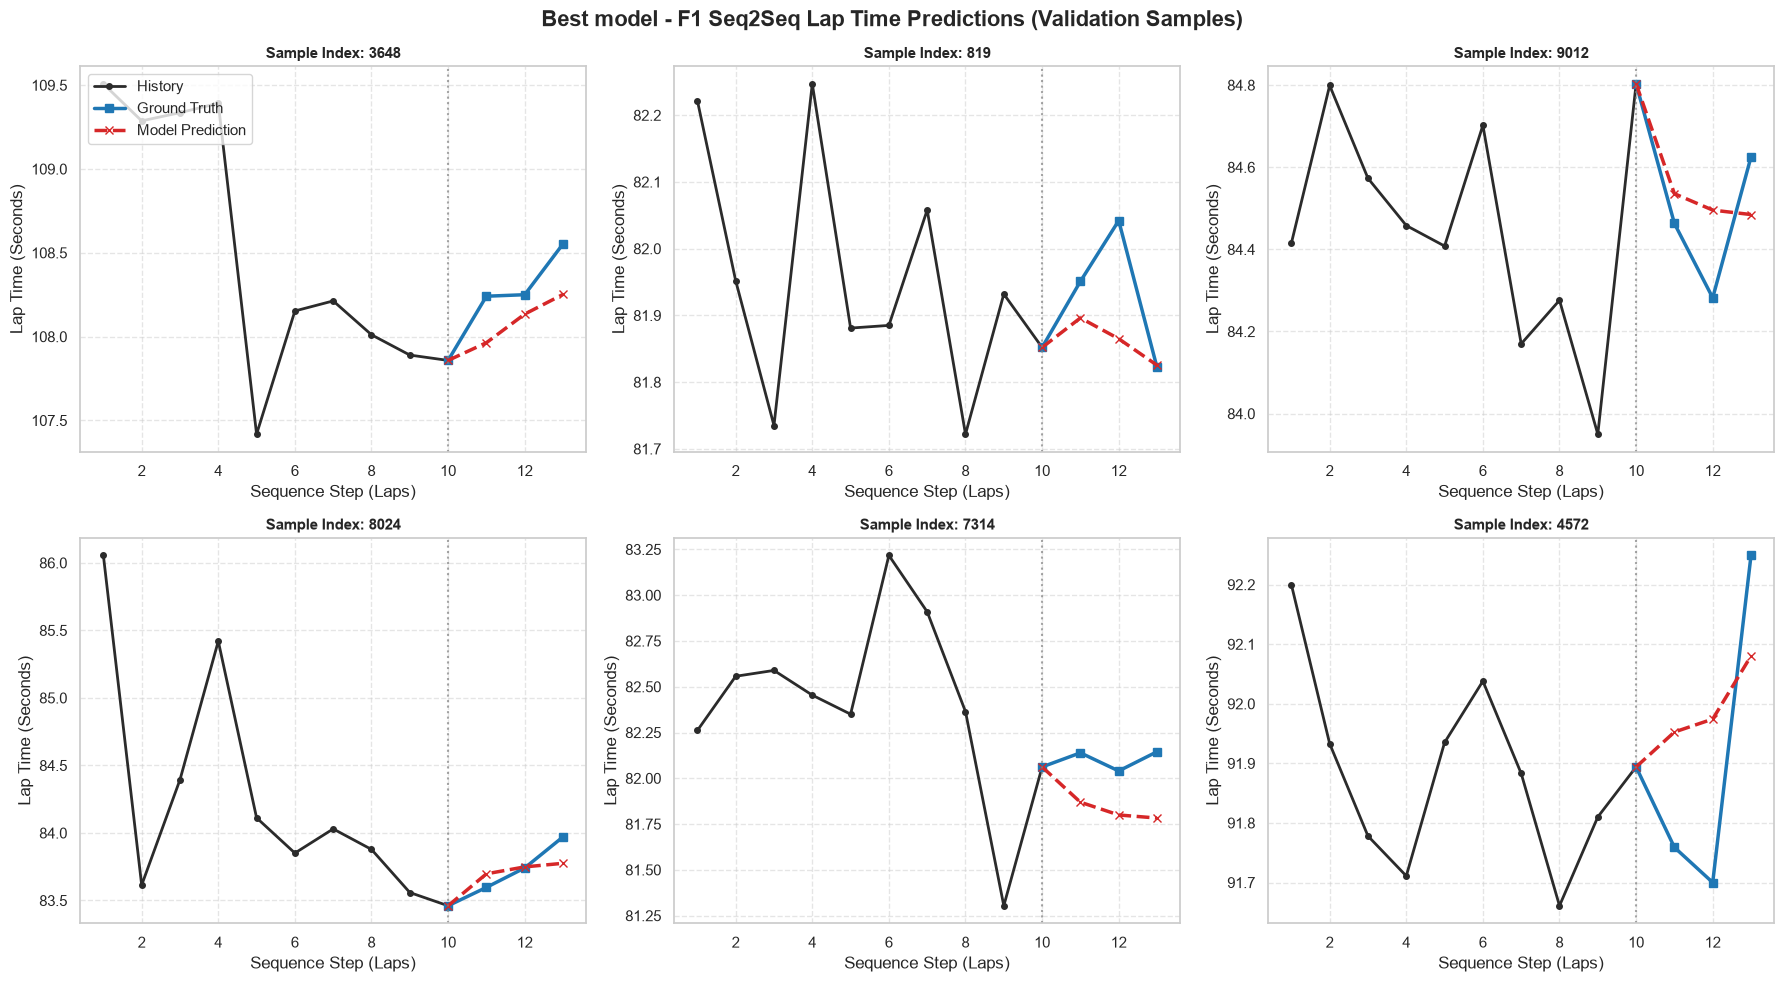

Saved F1 Seq2Seq Lap Time Predictions plot to: plots\Best_Model\03_best_Test_Predictions.png


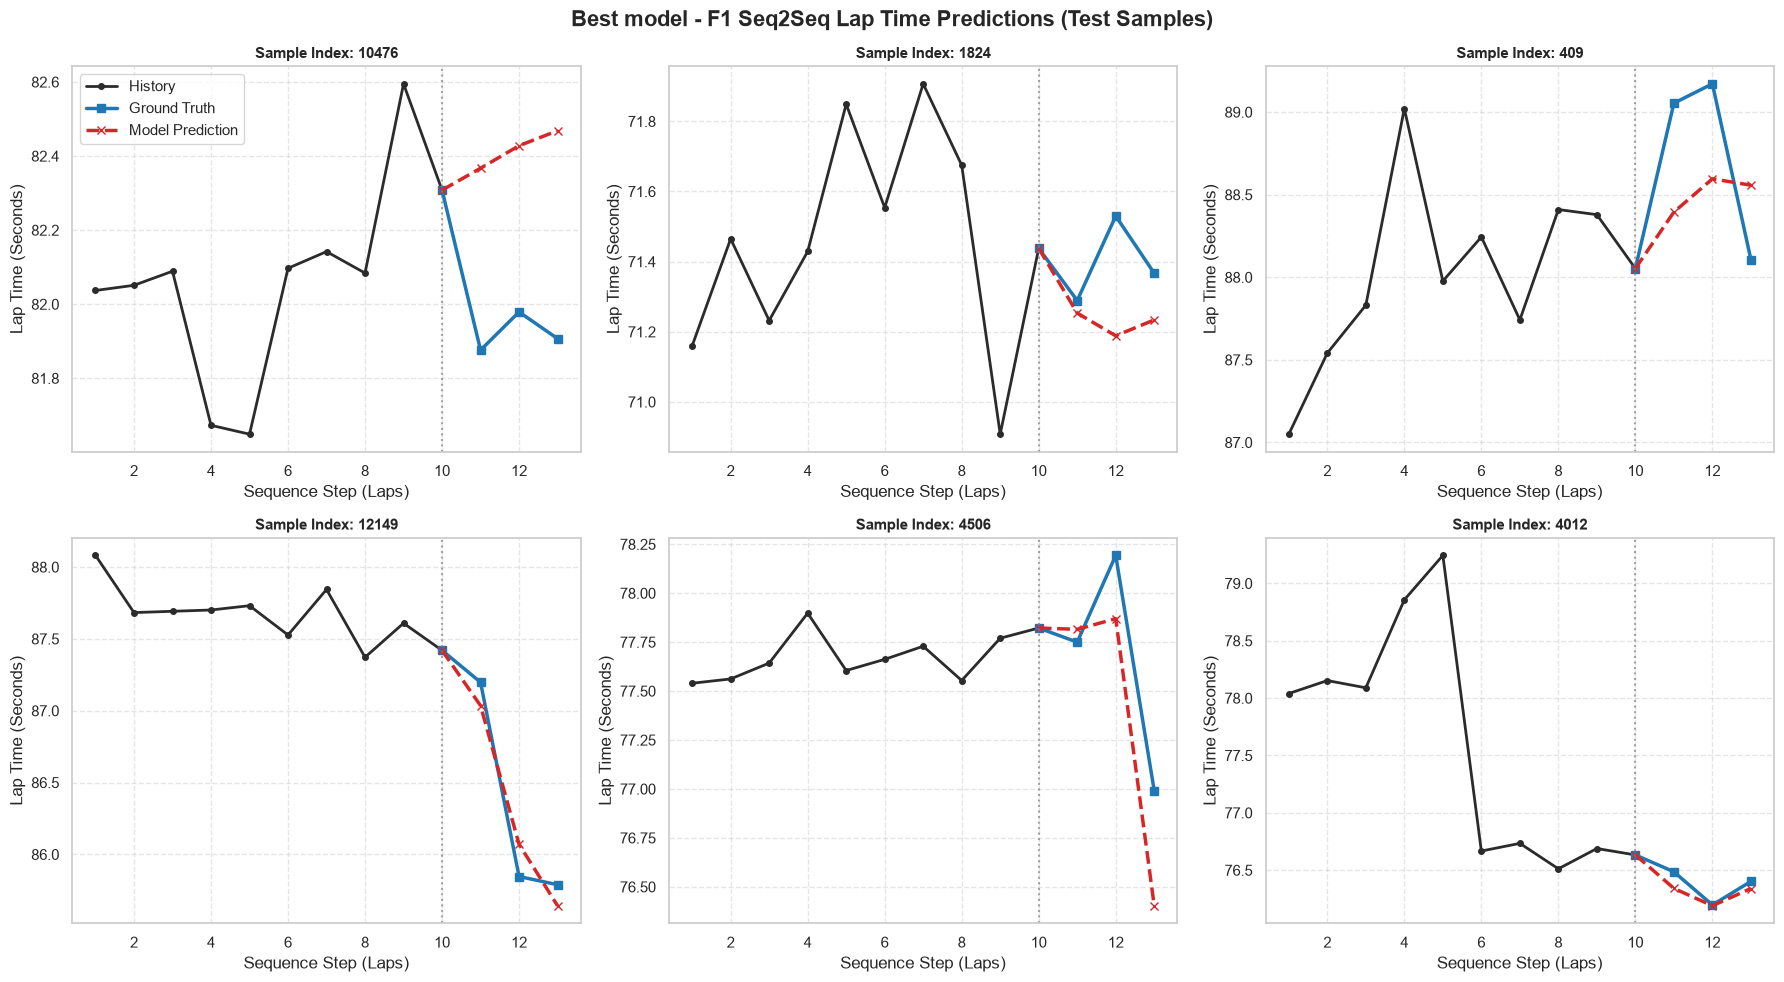

In [107]:
# Visualize the best model's predictions on a random selection of samples

plot_f1_predictions_grid(
    model=best_model_training_results['model'], 
    dataset=train_dataset,
    preprocessor=preprocessor,
    title="Best model - F1 Seq2Seq Lap Time Predictions (Training Samples)",
    path=best_model_plots_dir / "01_best_Train_Predictions.png"
)

plot_f1_predictions_grid(
    model=best_model_training_results['model'], 
    dataset=val_dataset,
    preprocessor=preprocessor,
    title="Best model - F1 Seq2Seq Lap Time Predictions (Validation Samples)",
    path=best_model_plots_dir / "02_best_Val_Predictions.png"
)

plot_f1_predictions_grid(
    model=best_model_training_results['model'], 
    dataset=test_dataset,
    preprocessor=preprocessor,
    title="Best model - F1 Seq2Seq Lap Time Predictions (Test Samples)",
    path=best_model_plots_dir / "03_best_Test_Predictions.png"
)

Saved Forecast Horizon Error Decay plot to: plots\Best_Model\04_best_Val_Forecast_Horizon_Error_Decay.png


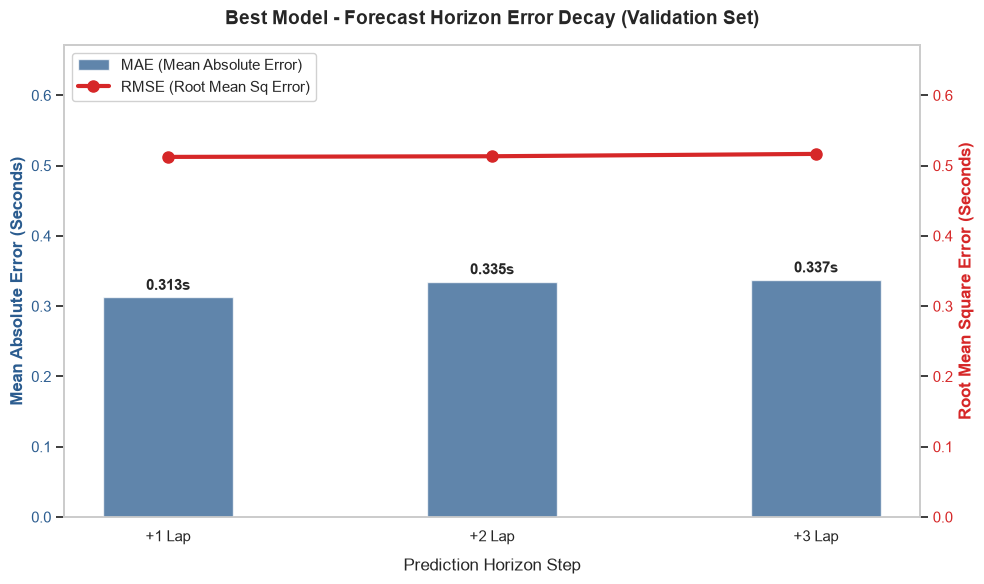

Saved Forecast Horizon Error Decay plot to: plots\Best_Model\05_best_Test_Forecast_Horizon_Error_Decay.png


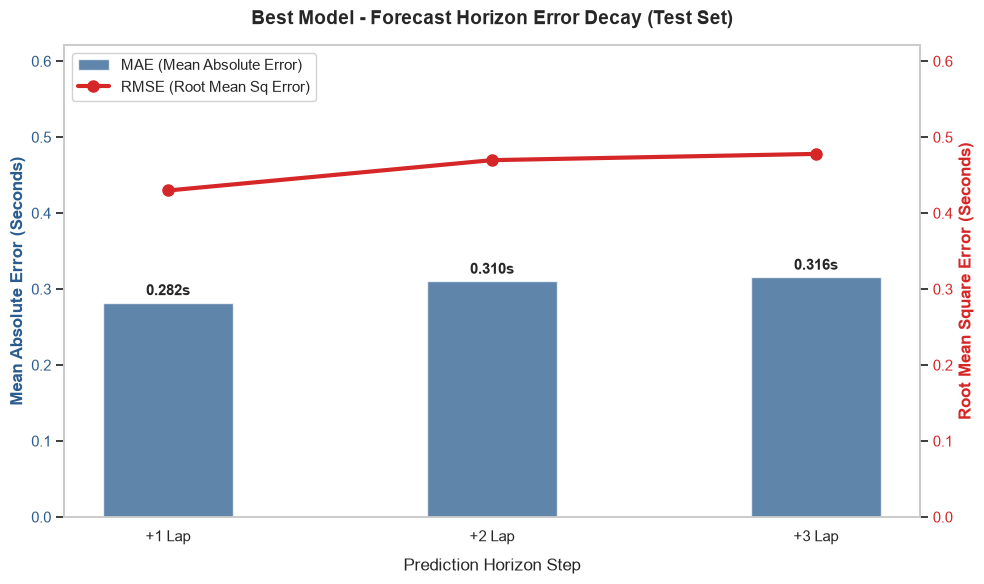

In [115]:
# Visualize the Forecast Horizon Error Decay for the validation and Test dataset using the tuned model

plot_forecast_horizon_error_decay(
    model=best_model_training_results['model'],
    dataset=val_dataset,
    preprocessor=preprocessor,
    device='cuda',
    title="Best Model - Forecast Horizon Error Decay (Validation Set)",
    path=best_model_plots_dir / "04_best_Val_Forecast_Horizon_Error_Decay.png"
)

plot_forecast_horizon_error_decay(
    model=best_model_training_results['model'],
    dataset=test_dataset,
    preprocessor=preprocessor,
    device='cuda',
    title="Best Model - Forecast Horizon Error Decay (Test Set)",
    path=best_model_plots_dir / "05_best_Test_Forecast_Horizon_Error_Decay.png"
)

Saved Residual Distribution Plot to plots\Best_Model\06_best_Val_Error_Residual_Distribution.png


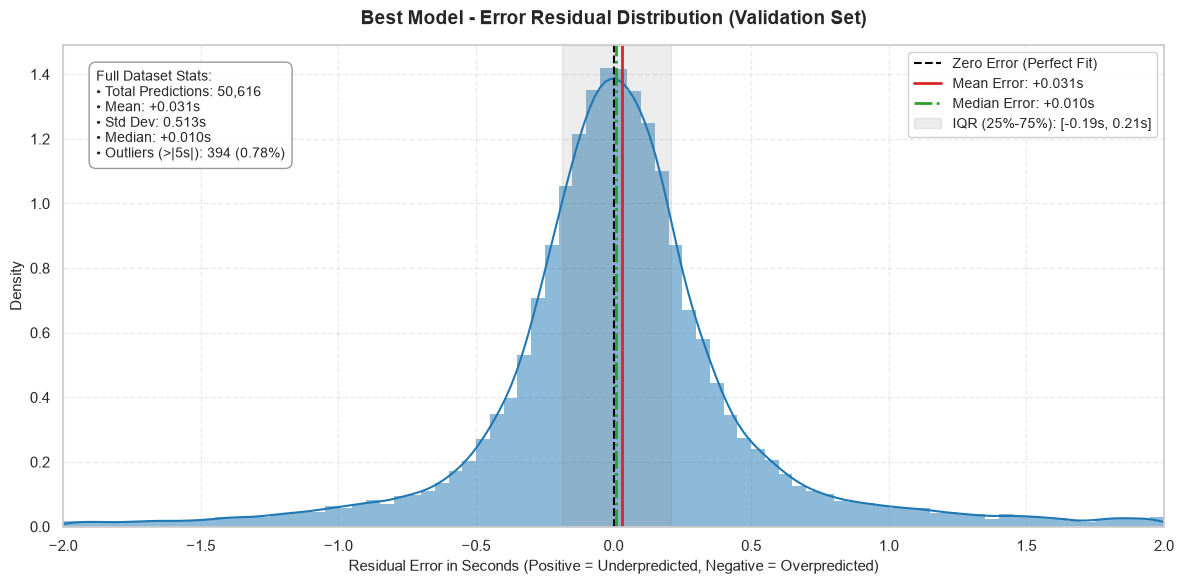

Saved Residual Distribution Plot to plots\Best_Model\07_best_Test_Error_Residual_Distribution.png


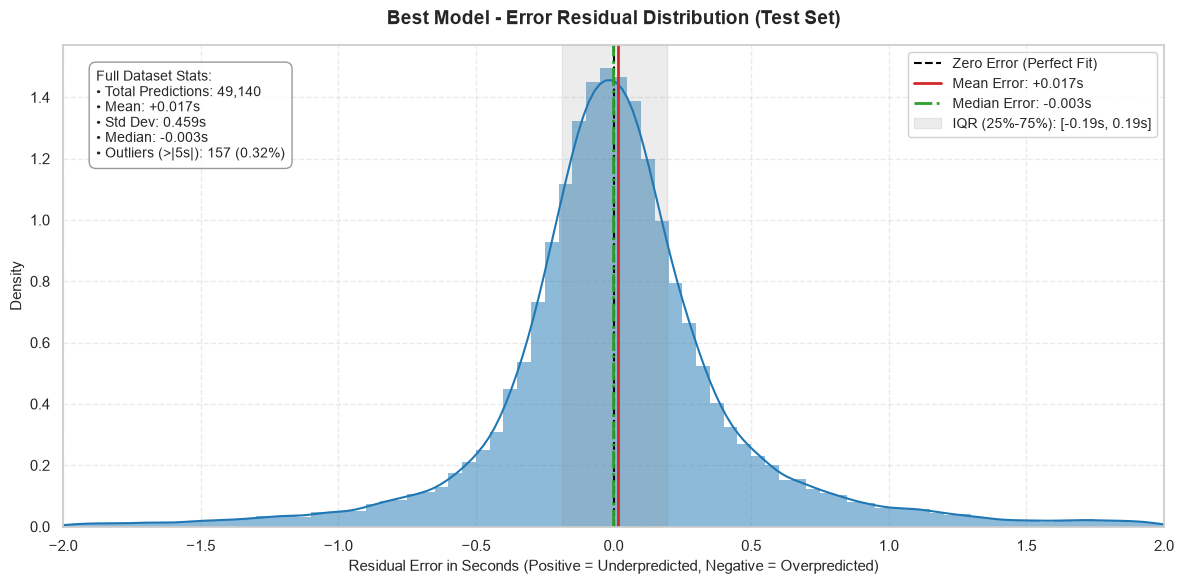

In [105]:
# Visualize the Error Residual Distribution for the validation dataset using the tuned model
plot_error_residual_distribution(
    model=best_model_training_results['model'],
    dataset=val_dataset,
    preprocessor=preprocessor,
    device='cuda',
    title="Best Model - Error Residual Distribution (Validation Set)",
    path=best_model_plots_dir / "06_best_Val_Error_Residual_Distribution.png"
)

plot_error_residual_distribution(
    model=best_model_training_results['model'],
    dataset=test_dataset,
    preprocessor=preprocessor,
    device='cuda',
    title="Best Model - Error Residual Distribution (Test Set)",
    path=best_model_plots_dir / "07_best_Test_Error_Residual_Distribution.png"
)

In [94]:
# print the original hyperparameters and the best hyperparameters found from the Optuna optimization

base_model_val_loss = model_training_results['best_val_loss']

best_model_val_loss = best_model_training_results['best_val_loss']

print("\n" + "="*60)
print(f"Base Model Validation Loss: {base_model_val_loss:.4f}")
print(f"Best Model Validation Loss: {best_model_val_loss:.4f}")


Base Model Validation Loss: 0.2414
Best Model Validation Loss: 0.2379


# Permutation Importance of Features